# Лабораторная работа 2. Исследовательский анализ данных

**Выполнил:** Моисеев Г. В., группа 4414

**Вариант 16.** Набор данных `drivers.csv`. В методичке 15 вариантов, поэтому номер взят по кругу: 16 → 1, задания варианта 1.

**Цель работы:** изучение связи между признаками двумерного набора данных, визуализация данных.

## 1. Загрузка данных

Набор данных содержит информацию о поездках в такси, каждая строка — одна поездка.

| Столбец | Что хранит |
|---|---|
| `START_DATE*` | дата и время начала поездки |
| `END_DATE*` | дата и время окончания поездки |
| `CATEGORY*` | категория поездки: `Business` (деловая) или `Personal` (личная) |
| `START*` | место начала поездки |
| `STOP*` | место окончания поездки |
| `MILES*` | пройденное расстояние, мили |
| `PURPOSE*` | цель поездки |
| `time` | длительность поездки, минуты |
| `speed` | средняя скорость, мили в час |
| `price` | стоимость поездки |

Файл читается из папки `data`, если ноутбук запущен локально. В Colab такой папки нет, и тогда файл скачивается из репозитория на GitHub.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_FILE = Path('data/drivers.csv')
DATA_URL = 'https://raw.githubusercontent.com/Echways/IDA/main/lab-2/data/drivers.csv'

raw = pd.read_csv(DATA_FILE if DATA_FILE.exists() else DATA_URL)
raw.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,time,speed,price
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,6.0,51.000000,788.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,12.0,25.000000,1237.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,13.0,22.153846,1312.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,14.0,20.142857,1387.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,67.0,57.044776,5376.0


In [2]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1099 entries, 0 to 1098
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1099 non-null   object 
 1   END_DATE*    1099 non-null   object 
 2   CATEGORY*    1099 non-null   object 
 3   START*       1099 non-null   object 
 4   STOP*        1099 non-null   object 
 5   MILES*       1099 non-null   float64
 6   PURPOSE*     598 non-null    object 
 7   time         1099 non-null   float64
 8   speed        1099 non-null   float64
 9   price        1099 non-null   float64
dtypes: float64(4), object(6)
memory usage: 86.0+ KB


В таблице 1099 строк и 10 столбцов. Пропуски есть только в `PURPOSE*`: заполнено 598 значений из 1099. Даты прочитались как строки (`object`), `time` и `price` — как `float64`.

In [3]:
raw.describe()

,MILES*,time,speed,price
count,1099.000000,1099.000000,1099.000000,1099.000000
mean,10.803094,23.300273,inf,2085.929936
std,22.044580,27.745836,NaN,2084.368402
min,0.500000,0.000000,3.917355,337.000000
25%,2.900000,10.000000,15.346667,1087.000000
50%,6.000000,16.000000,21.333333,1539.000000
75%,10.500000,27.000000,28.915033,2365.500000
max,310.300000,336.000000,inf,25569.000000


Среднее и максимум скорости равны `inf`, а стандартное отклонение не посчиталось (`NaN`). Значит, в `speed` есть бесконечные значения. У `time` минимум равен 0: скорость получается делением расстояния на длительность, и при нулевой длительности выходит деление на ноль.

## 2. Предобработка

Предобработка этого набора данных уже выполнялась в лабораторной работе 1: звёздочка в названиях столбцов, пропуски в цели поездки, типы дат, `time` и `price`. Здесь те же шаги повторены, чтобы ноутбук работал сам по себе, и добавлена проверка скорости, которая в первой работе не понадобилась: теперь `speed` участвует в анализе.

In [4]:
MAX_SPEED = 100

speed = raw['speed']
too_fast = np.isfinite(speed) & (speed > MAX_SPEED)
print('Бесконечная скорость:', np.isinf(speed).sum())
print('Скорость выше 100 миль/ч:', too_fast.sum())
print('Явные дубликаты:', raw.duplicated().sum())

Бесконечная скорость: 4
Скорость выше 100 миль/ч: 15
Явные дубликаты: 0


Бесконечная скорость у четырёх поездок с нулевой длительностью. Ещё у 15 поездок скорость больше 100 миль/ч — для такси это нереально. Эти поездки:

In [5]:
columns = ['START*', 'STOP*', 'MILES*', 'time', 'speed', 'price']
raw.loc[too_fast, columns].sort_values('speed')

,START*,STOP*,MILES*,time,speed,price
335,Raleigh,Cary,32.8,19.0,103.578947,1771.0
932,San Francisco,Oakland,9.9,5.0,118.800000,715.0
752,Unknown Location,Unknown Location,8.6,4.0,129.000000,639.0
761,Unknown Location,Unknown Location,9.4,4.0,141.000000,640.0
798,Karachi,Unknown Location,8.0,3.0,160.000000,564.0
772,Unknown Location,Unknown Location,5.8,2.0,174.000000,489.0
121,Unknown Location,Unknown Location,23.5,8.0,176.250000,944.0
780,Unknown Location,Islamabad,10.5,3.0,210.000000,565.0
375,Morrisville,Raleigh,7.6,2.0,228.000000,489.0
753,Unknown Location,Unknown Location,9.8,2.0,294.000000,490.0


Почти у всех таких поездок длительность 1–8 минут при расстоянии 6–33 мили: например, 15.1 мили за 1 минуту. Длительность записана с ошибкой, а вместе с ней ошибочны скорость и стоимость — стоимость, как видно дальше в разделе 5, считается по времени. Исправить эти значения нечем, поэтому 19 поездок (4 с нулевой длительностью и 15 слишком быстрых) удаляю. Бесконечная скорость тоже больше 100, так что оба случая отсекаются одним условием.

Шаги предобработки — отдельные функции, каждая принимает датафрейм и возвращает новый. В цепочку они собираются через `pipe`:

- `strip_column_marks` — убирает `*` в конце названий столбцов;
- `drop_impossible_trips` — удаляет поездки со скоростью выше 100 миль/ч;
- `fill_missing_purpose` — заменяет пропуски в цели поездки на «не определена»: пропусков 501, и удалять почти половину строк нельзя;
- `convert_types` — переводит даты в `datetime`, а `time` и `price` в `int64` (дробных значений в них нет, это проверено в ЛР1).

Явных дубликатов нет, неявных в `CATEGORY` и `PURPOSE` тоже нет — это проверено в ЛР1.

In [6]:
UNKNOWN_PURPOSE = 'не определена'


def strip_column_marks(trips: pd.DataFrame) -> pd.DataFrame:
    return trips.rename(columns=lambda name: name.rstrip('*'))


def drop_impossible_trips(trips: pd.DataFrame) -> pd.DataFrame:
    return trips[trips['speed'] <= MAX_SPEED].reset_index(drop=True)


def fill_missing_purpose(trips: pd.DataFrame) -> pd.DataFrame:
    return trips.fillna({'PURPOSE': UNKNOWN_PURPOSE})


def convert_types(trips: pd.DataFrame) -> pd.DataFrame:
    dates = {column: pd.to_datetime(trips[column])
             for column in ['START_DATE', 'END_DATE']}
    return trips.assign(**dates).astype({'time': 'int64', 'price': 'int64'})


trips = (raw.pipe(strip_column_marks)
            .pipe(drop_impossible_trips)
            .pipe(fill_missing_purpose)
            .pipe(convert_types))
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1080 non-null   datetime64[ns]
 1   END_DATE    1080 non-null   datetime64[ns]
 2   CATEGORY    1080 non-null   object        
 3   START       1080 non-null   object        
 4   STOP        1080 non-null   object        
 5   MILES       1080 non-null   float64       
 6   PURPOSE     1080 non-null   object        
 7   time        1080 non-null   int64         
 8   speed       1080 non-null   float64       
 9   price       1080 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 84.5+ KB


In [7]:
trips.describe(include='number')

,MILES,time,speed,price
count,1080.000000,1080.000000,1080.000000,1080.000000
mean,10.624074,23.637963,23.480030,2111.171296
std,21.915269,27.862489,12.485450,2093.207943
min,0.500000,1.000000,3.917355,412.000000
25%,2.800000,10.000000,15.223077,1087.000000
50%,6.000000,17.000000,21.107280,1611.000000
75%,10.500000,28.000000,28.500000,2437.000000
max,310.300000,336.000000,91.500000,25569.000000


После обработки осталось 1080 поездок, пропусков нет.

- `MILES` — от 0.5 до 310.3 мили, медиана 6, среднее 10.6. Среднее почти вдвое больше медианы: несколько дальних поездок тянут его вверх.
- `time` — от 1 до 336 минут, медиана 17.
- `speed` — от 3.9 до 91.5 мили в час, медиана 21.1. Стандартное отклонение упало с бесконечности до 12.5.
- `price` — от 412 до 25 569, медиана 1611, среднее 2111.

## 3. Матрица диаграмм рассеяния

Названия признаков для подписей осей собраны в словаре `LABELS`, чтобы не повторять их в каждом графике. `MIN_TRIPS` — минимальное число поездок, при котором цель поездки показывается на графиках: по одной-двум поездкам распределение не построить.

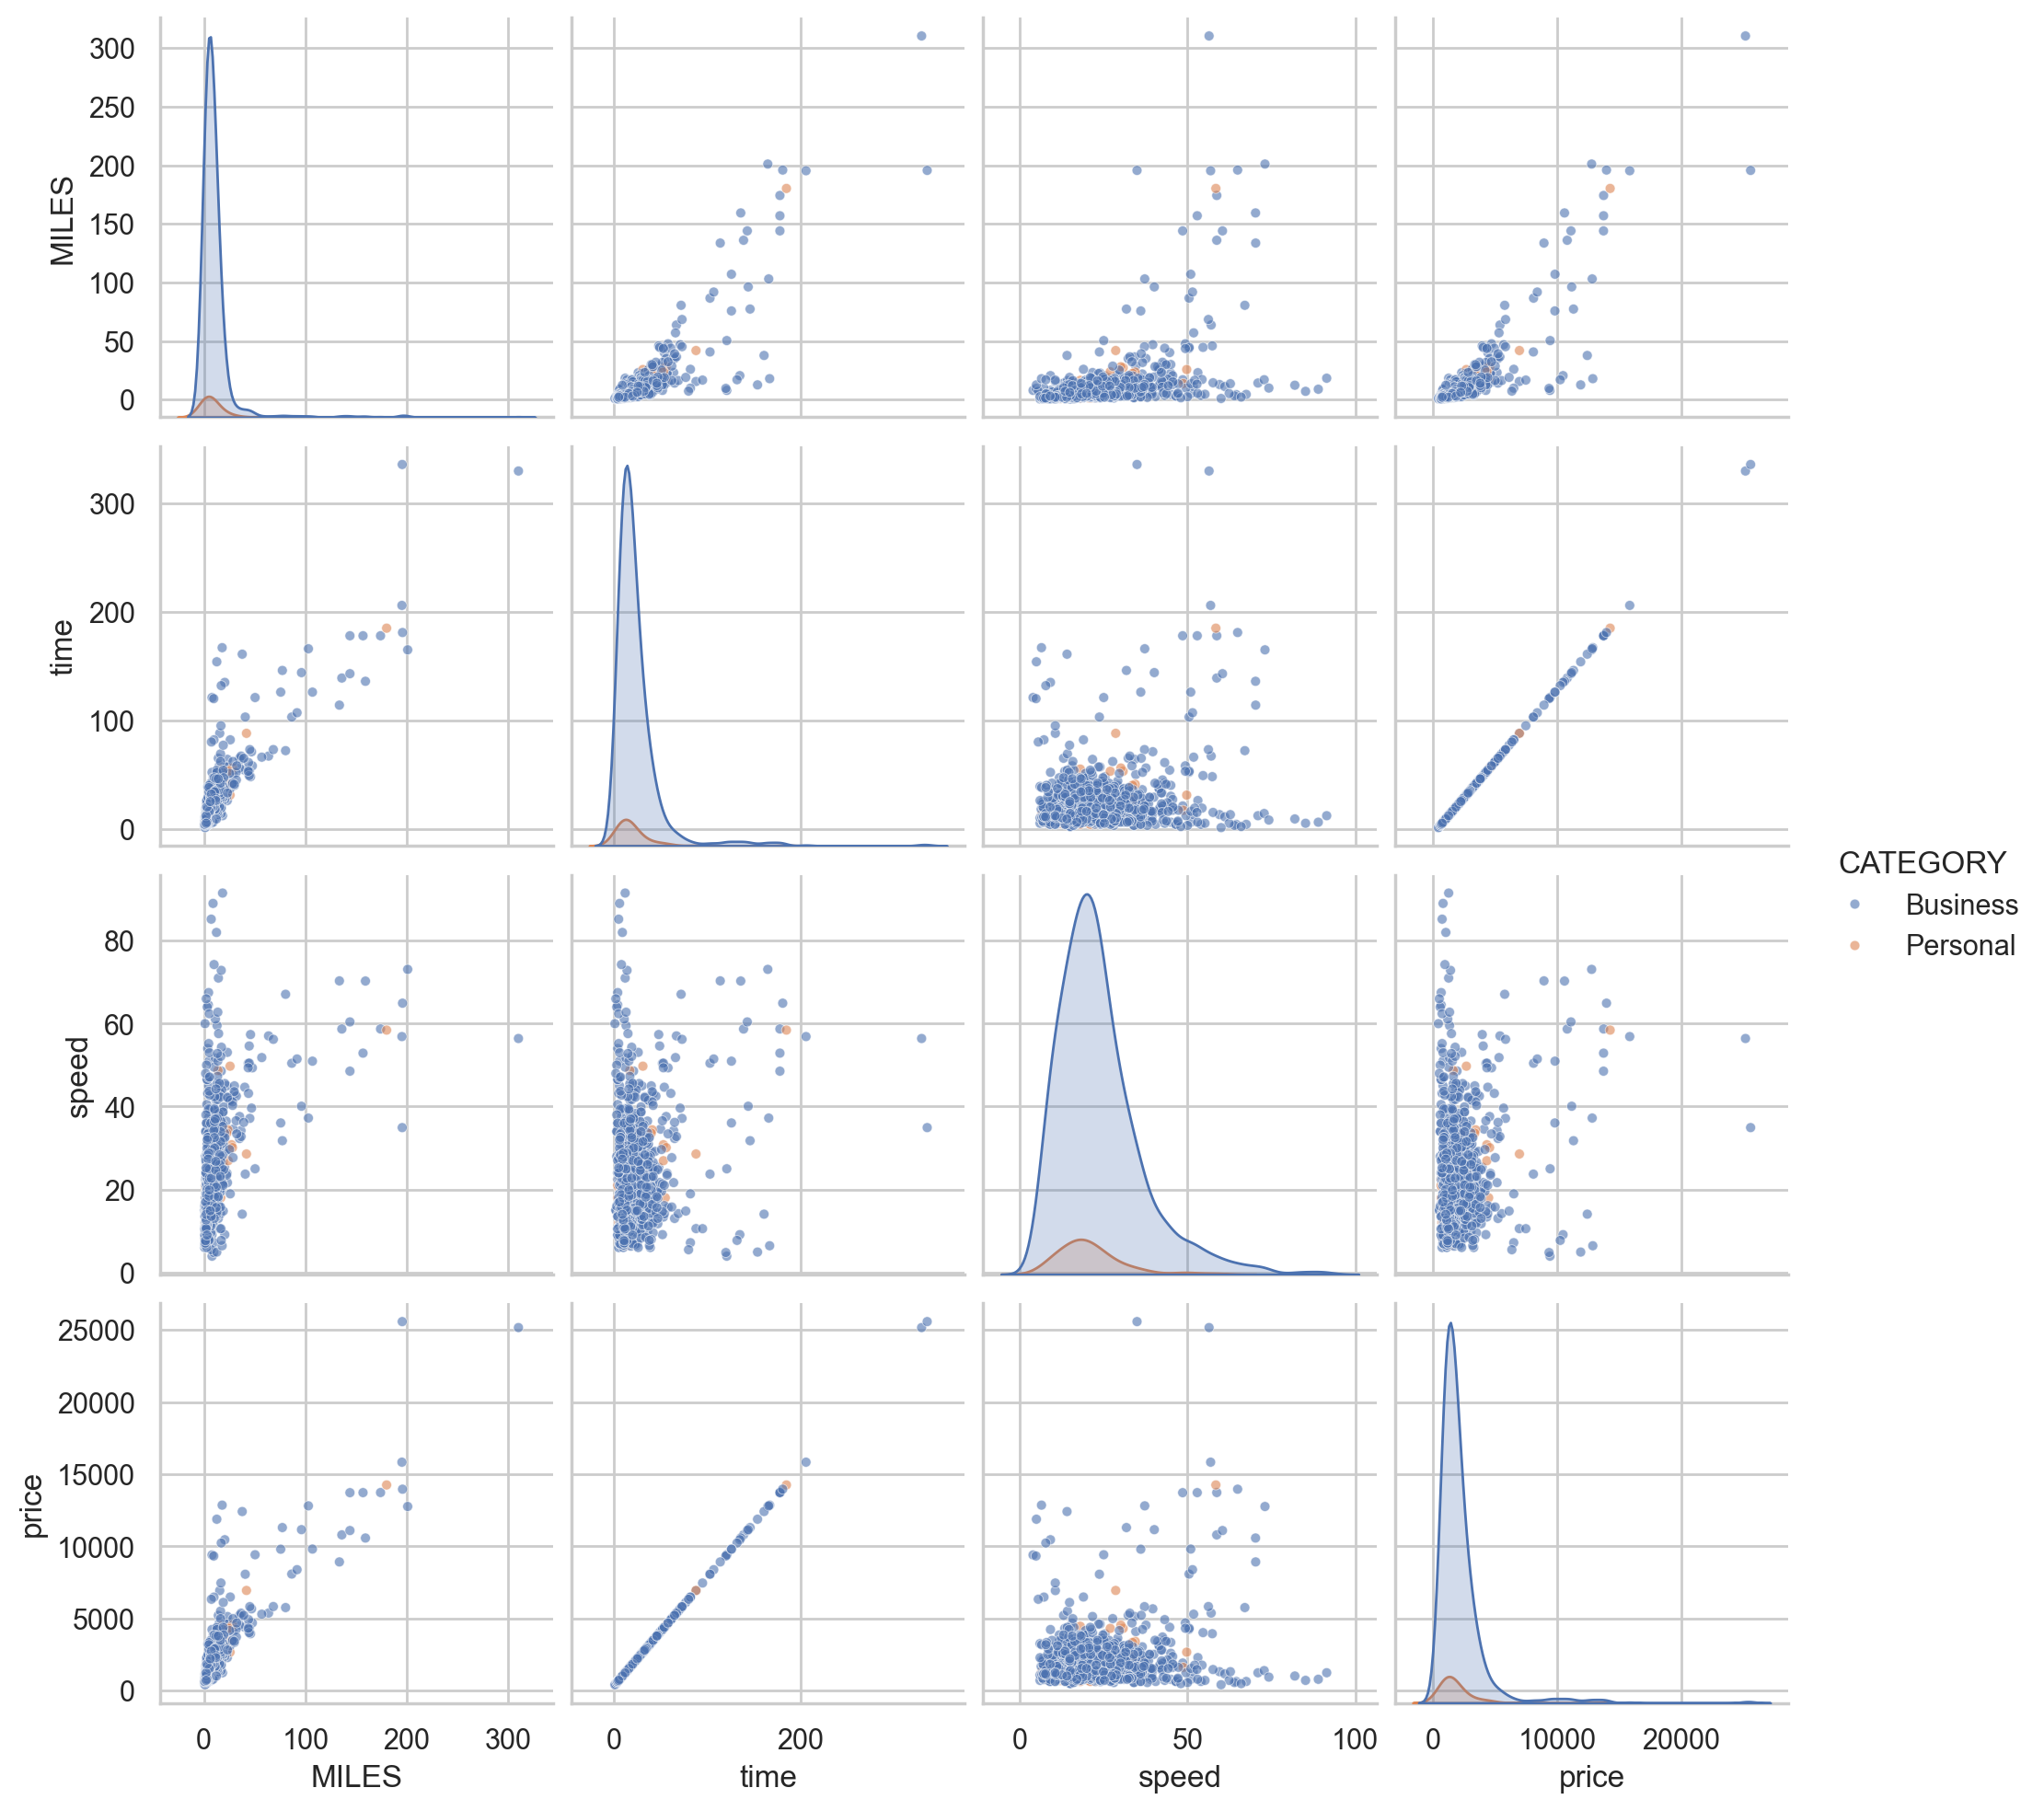

In [8]:
LABELS = {
    'MILES': 'Расстояние, мили',
    'time': 'Длительность, мин',
    'speed': 'Скорость, миль/ч',
    'price': 'Стоимость',
}
NUMERIC = list(LABELS)
MIN_TRIPS = 5

sns.pairplot(trips, vars=NUMERIC, hue='CATEGORY', plot_kws={'s': 15, 'alpha': 0.6})
plt.show()

- `time` и `price` лежат на одной прямой: стоимость полностью определяется длительностью.
- `MILES` связан с `time` и `price` прямой зависимостью: чем дальше поездка, тем она дольше и дороже. Разброс растёт с расстоянием — одно и то же расстояние можно проехать за разное время.
- `speed` слабо связан с `time` и `price`. У поездок до 5 миль скорость разбросана от 6 до 68 миль/ч, а у поездок длиннее 50 миль она не опускается ниже 25 — это поездки по трассе.
- Точки личных поездок (`Personal`) лежат в той же области, что и деловые, отдельной группы они не образуют.

Большинство точек сжато в левом нижнем углу, поэтому зависимость расстояния и длительности по целям поездки строю в логарифмическом масштабе. Поездки без цели на этом графике не показаны: их почти половина, и они закрывают остальные точки.

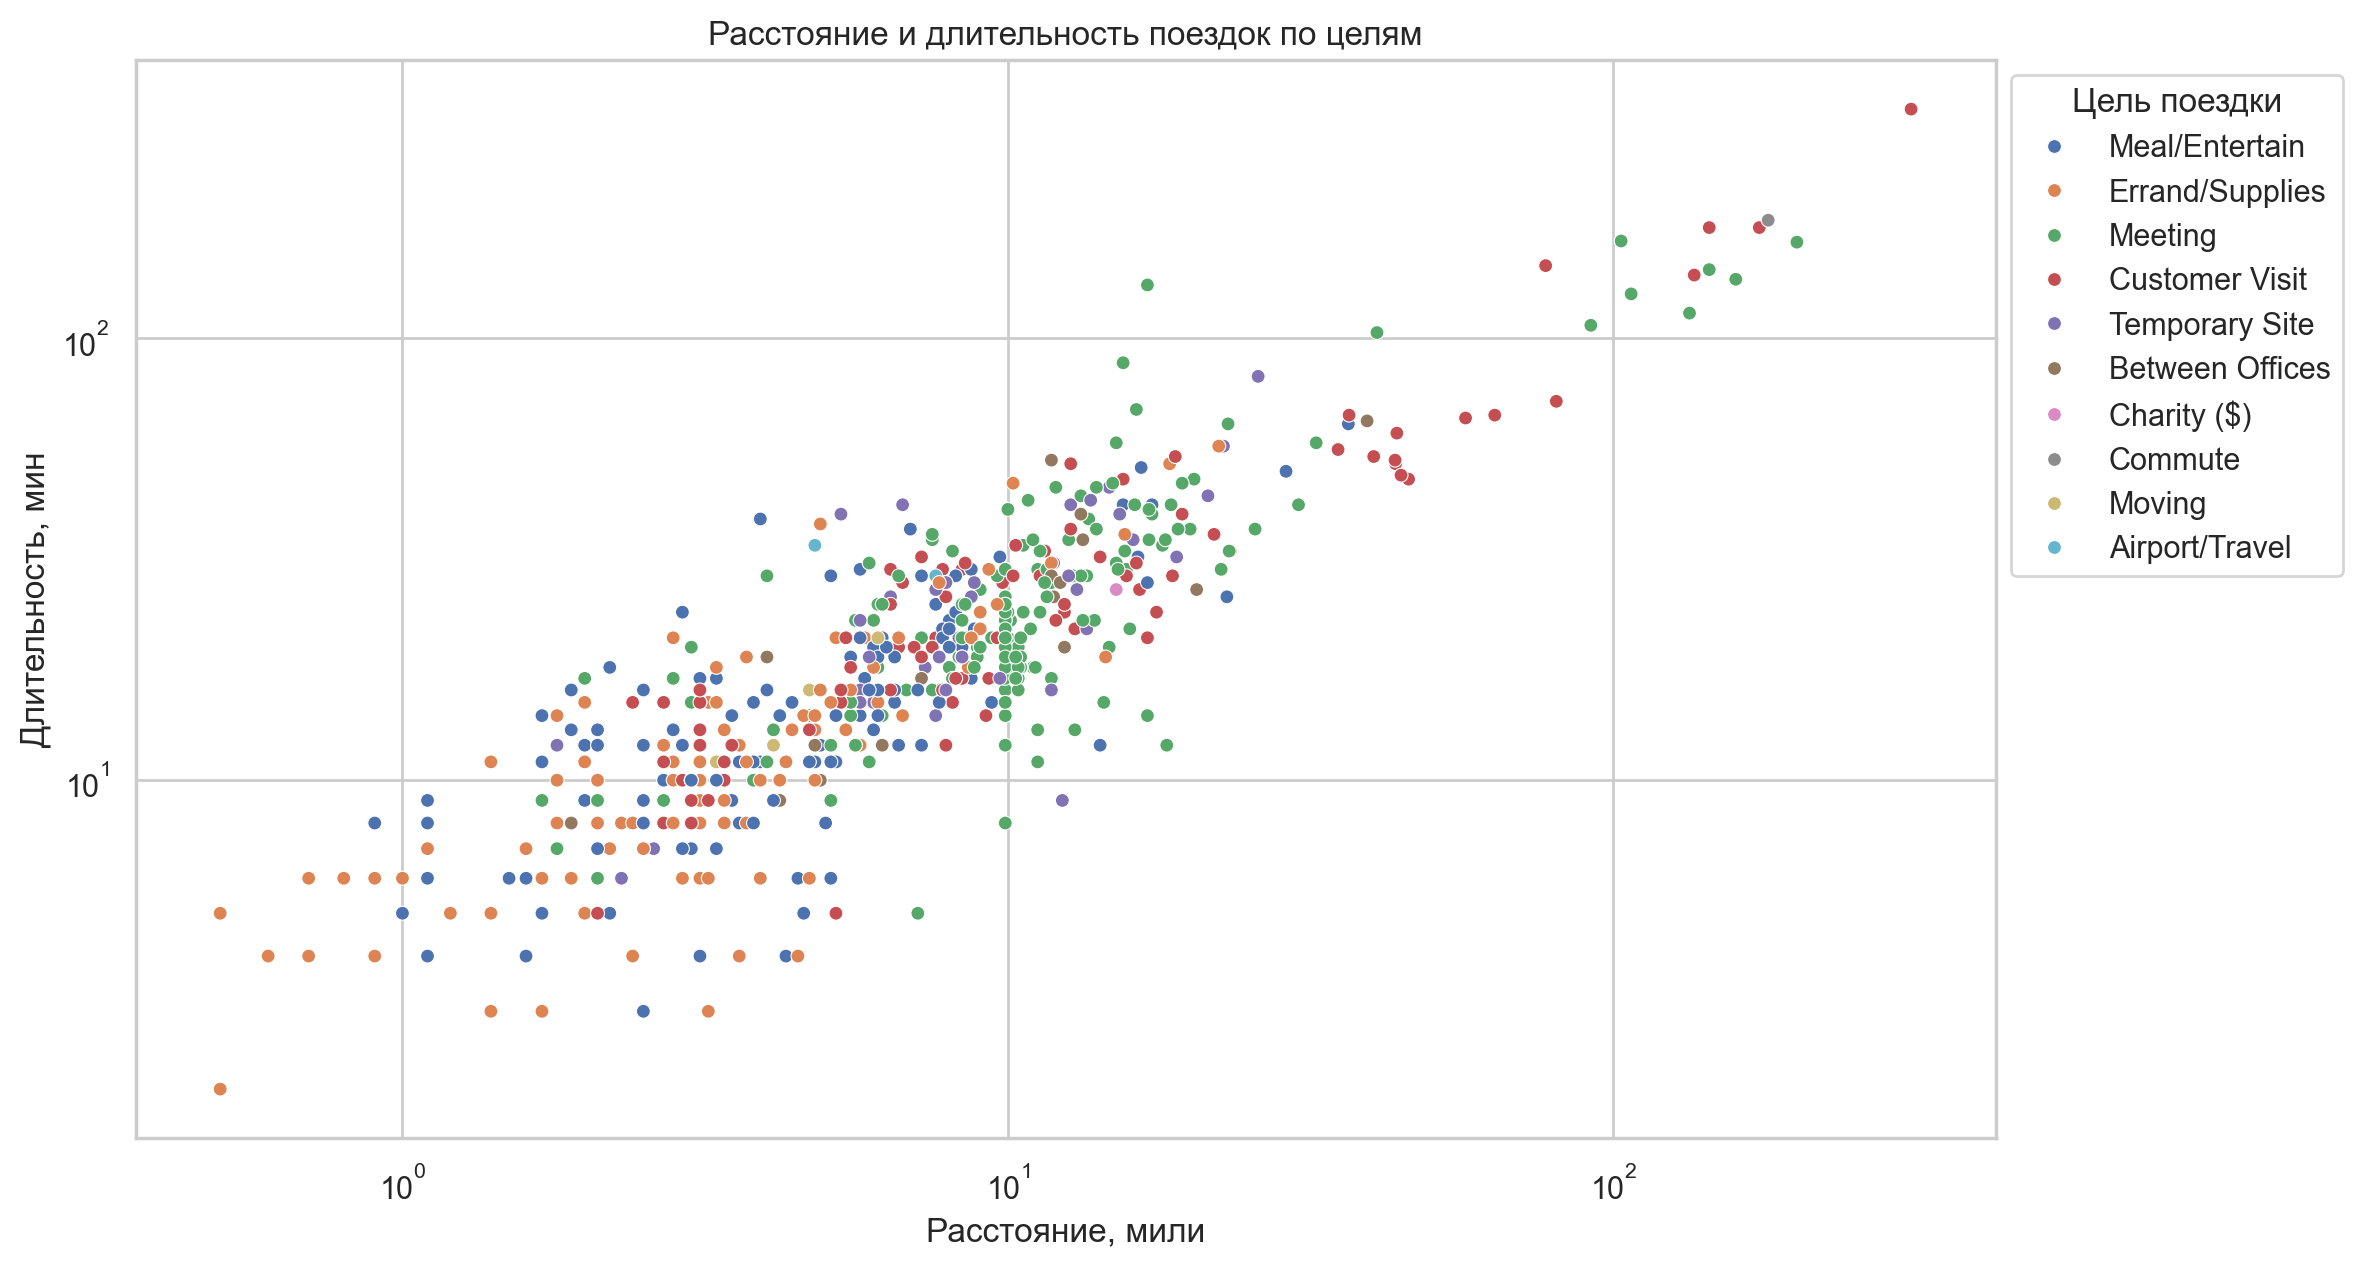

In [9]:
known_purpose = trips[trips['PURPOSE'] != UNKNOWN_PURPOSE]

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(data=known_purpose, x='MILES', y='time', hue='PURPOSE', s=25, ax=ax)
ax.set(xscale='log', yscale='log', xlabel=LABELS['MILES'], ylabel=LABELS['time'],
       title='Расстояние и длительность поездок по целям')
ax.legend(title='Цель поездки', bbox_to_anchor=(1, 1))
plt.show()

Точки вытянуты вдоль диагонали — длительность растёт вместе с расстоянием. Цели поездок занимают разные участки этой диагонали: Errand/Supplies и Meal/Entertain в основном до 10 миль, а в правой верхней части, дальше 30 миль, почти только Customer Visit и Meeting.

## 4. Гистограммы

Количество bins подбираю по правилу Фридмана — Диакониса: ширина интервала равна $2 \cdot IQR / \sqrt[3]{n}$. Правило опирается на межквартильный размах, поэтому на ширину интервала не влияют выбросы. В NumPy оно вызывается как `bins='fd'`.

В верхнем ряду гистограммы в обычной шкале, в нижнем — в логарифмической. Для нижнего ряда правило применено к логарифмам значений, границы интервалов получаются равными в логарифмической шкале.

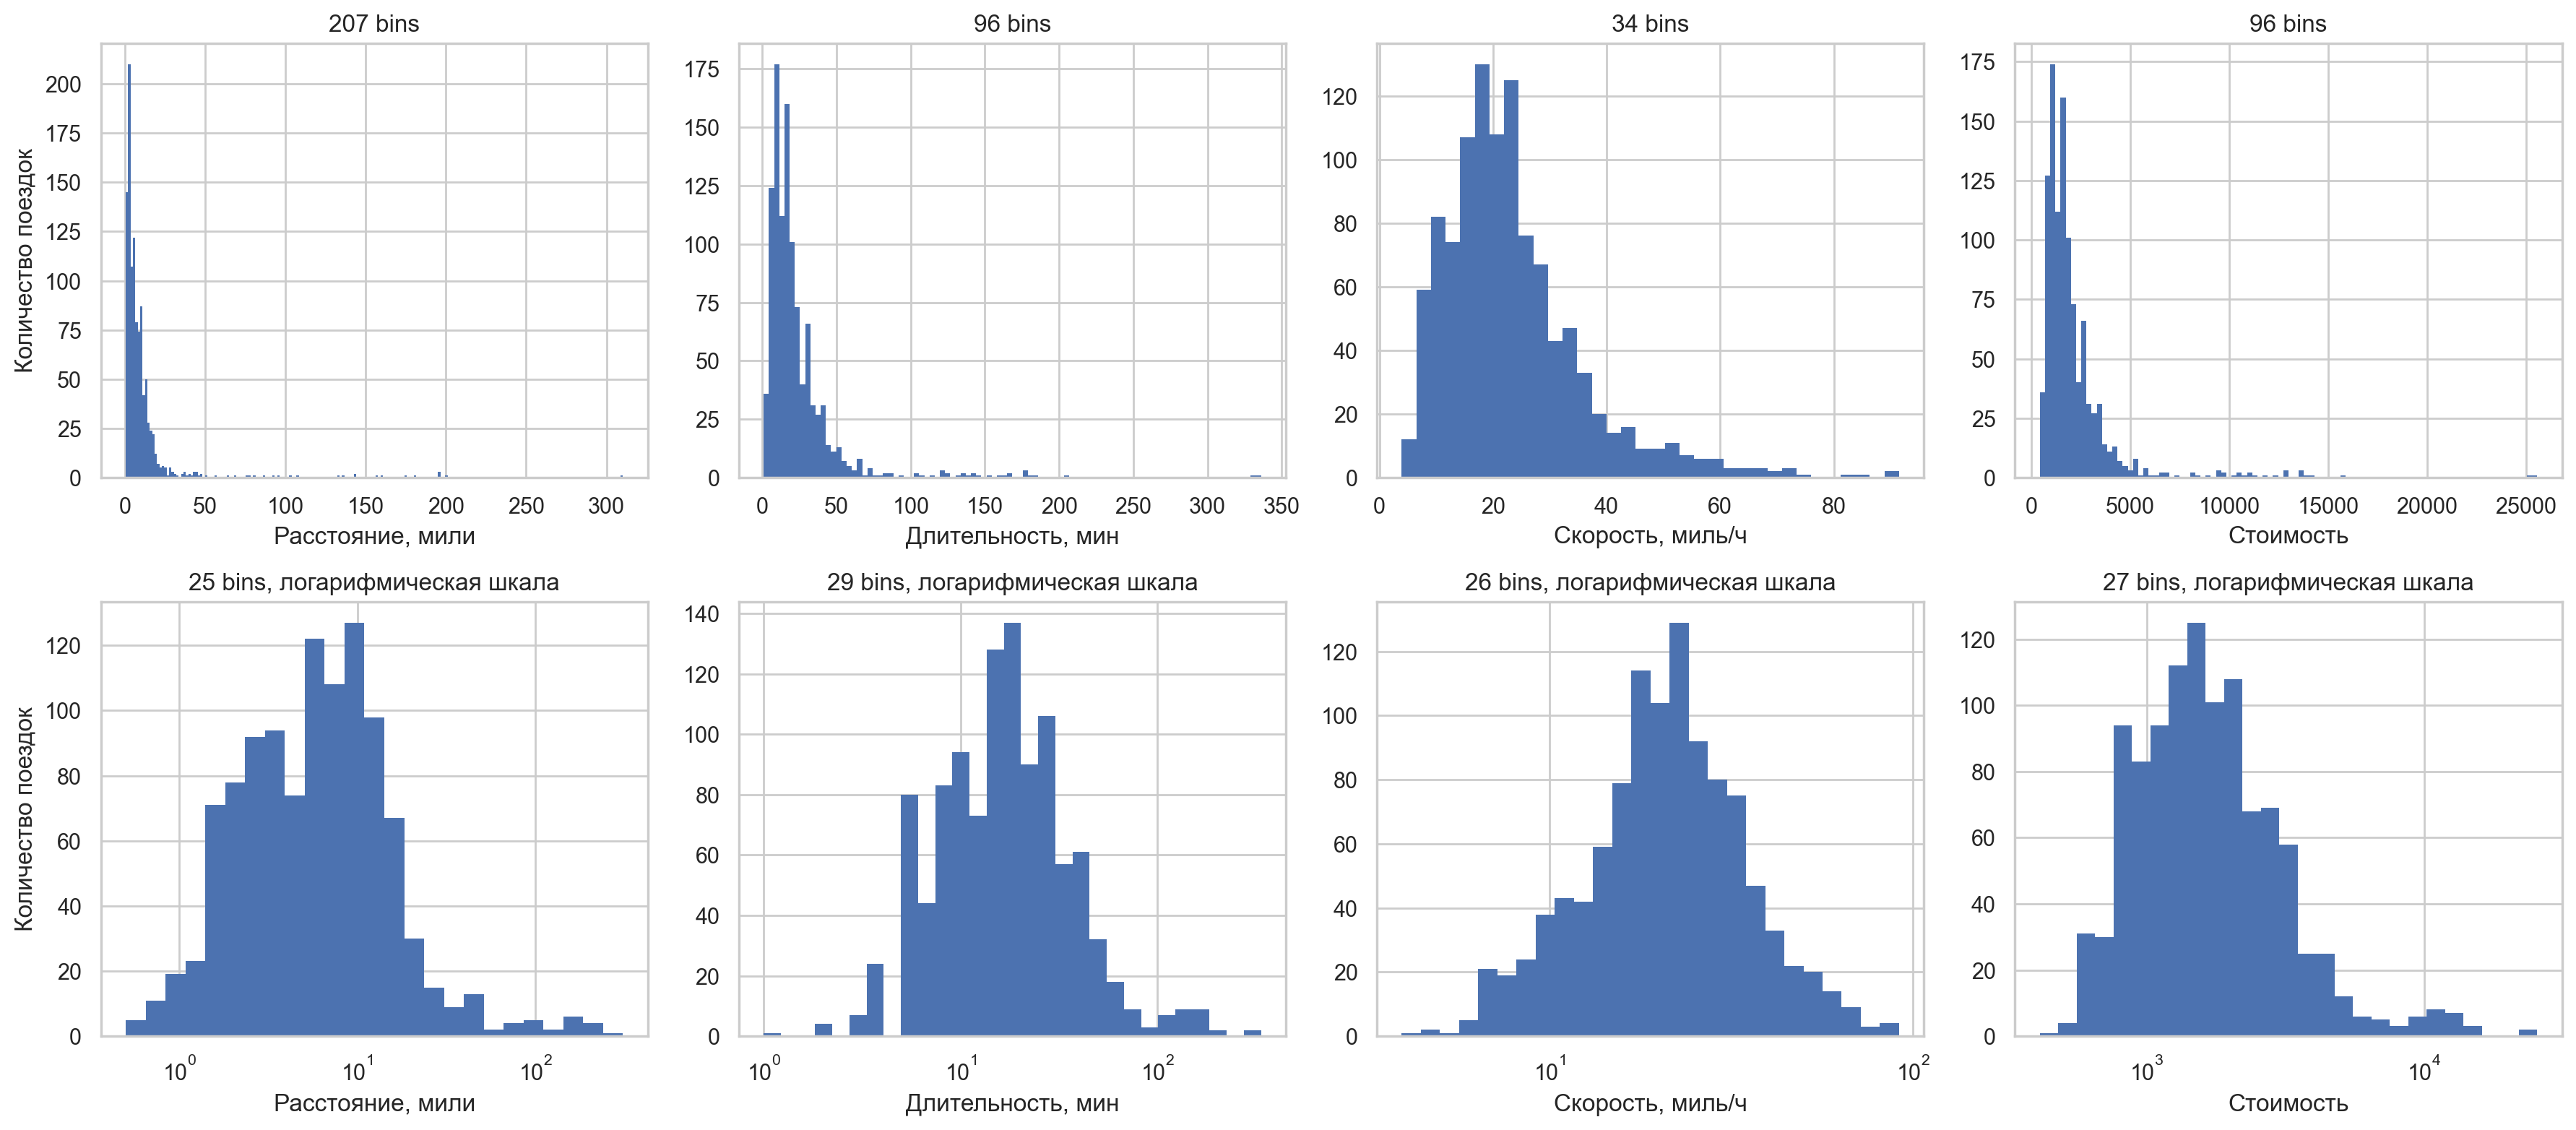

In [10]:
fig, axes = plt.subplots(2, len(NUMERIC), figsize=(18, 8))

for column, linear_ax, log_ax in zip(NUMERIC, *axes):
    values = trips[column]
    linear_bins = np.histogram_bin_edges(values, bins='fd')
    log_bins = 10 ** np.histogram_bin_edges(np.log10(values), bins='fd')

    linear_ax.hist(values, bins=linear_bins, linewidth=0)
    linear_ax.set(title=f'{len(linear_bins) - 1} bins', xlabel=LABELS[column])

    log_ax.hist(values, bins=log_bins, linewidth=0)
    log_ax.set(title=f'{len(log_bins) - 1} bins, логарифмическая шкала',
               xlabel=LABELS[column], xscale='log')

for ax in axes[:, 0]:
    ax.set_ylabel('Количество поездок')

fig.tight_layout()
plt.show()

В обычной шкале у `MILES`, `time` и `price` правило даёт 96–207 bins, но почти все поездки попадают в первые интервалы, а справа тянется длинный редкий хвост: 25 поездок длиннее 50 миль при медиане 6. Такие гистограммы показывают только асимметрию, форму основной массы на них не разглядеть. У `speed` хвост короче, и 34 bins хватает: распределение одновершинное, пик около 20 миль/ч, правая сторона длиннее левой.

В логарифмической шкале всем признакам хватает 25–29 bins, и распределения становятся похожи на колокол, то есть близки к логнормальному. Это обычно для величин, которые не бывают отрицательными и складываются из множества случайных факторов. У `time` слева видны пустые интервалы: длительность записана целыми минутами, и между 1, 2 и 3 минутами значений нет.

Для этих данных подходит логарифмическая шкала с 25–29 bins.

## 5. Корреляция и ковариация

Ковариация показывает, меняются ли две величины в одну сторону. Её значение зависит от единиц измерения, поэтому сравнивать ковариации разных пар нельзя. Корреляция — это ковариация, делённая на произведение стандартных отклонений, она всегда лежит в пределах от −1 до 1.

In [11]:
trips[NUMERIC].cov().round(1)

,MILES,time,speed,price
MILES,480.3,528.0,130.4,39701.1
time,528.0,776.3,82.5,58321.9
speed,130.4,82.5,155.9,6221.0
price,39701.1,58321.9,6221.0,4381519.5


Все ковариации положительные: ни один признак не уменьшается при росте другого. Величина ковариации определяется масштабом: у пар со стоимостью она измеряется десятками тысяч, потому что сама стоимость измеряется тысячами. О силе связи по этой таблице судить нельзя.

Коэффициент Пирсона оценивает линейную связь. Коэффициент Спирмена считается по рангам значений и показывает монотонную связь любой формы, он также меньше чувствителен к выбросам.

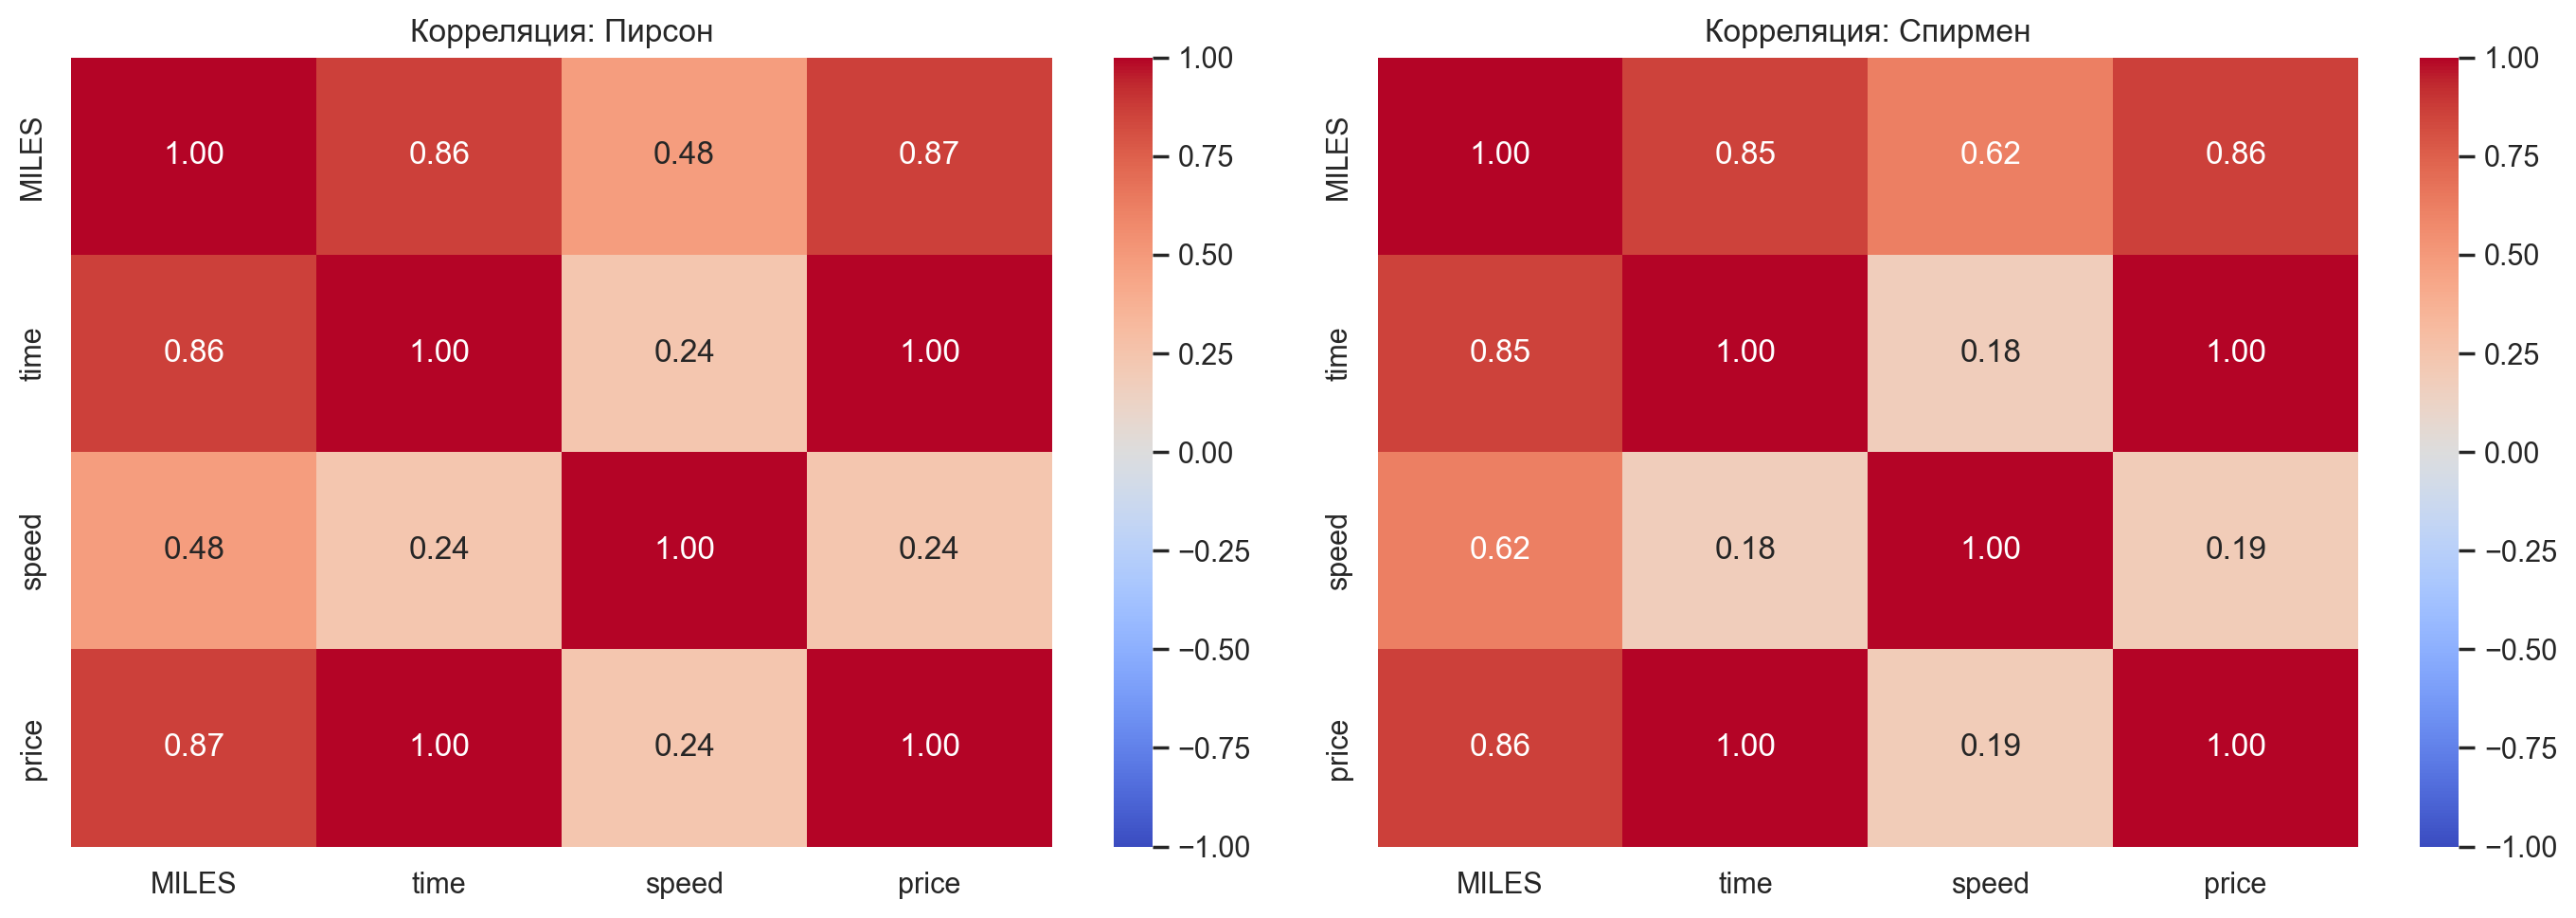

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, method, title in zip(axes, ['pearson', 'spearman'], ['Пирсон', 'Спирмен']):
    correlation = trips[NUMERIC].corr(method=method)
    sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'Корреляция: {title}')

fig.tight_layout()
plt.show()

- `time` и `price` — корреляция 1.00, связь линейная и полная.
- `MILES` с `time` и `price` — 0.85–0.87 по обоим методам, сильная линейная связь.
- `MILES` и `speed` — 0.48 по Пирсону и 0.62 по Спирмену. Связь средняя, и она скорее монотонная, чем линейная: скорость растёт с расстоянием, но всё медленнее.
- `speed` с `time` и `price` — 0.18–0.24, связь слабая. Долгая поездка может быть и дальней, и медленной из-за пробок.

Отрицательных корреляций нет. Так как корреляция `time` и `price` равна единице, проверяю, по какой формуле считается стоимость:

In [13]:
slope, intercept = np.polyfit(trips['time'], trips['price'], deg=1)
residuals = trips['price'] - (slope * trips['time'] + intercept)
print(f'price = {slope:.1f} * time + {intercept:.1f}')
print(f'Наибольшее отклонение от прямой: {residuals.abs().max():.0f}')

price = 75.1 * time + 335.3
Наибольшее отклонение от прямой: 29


Стоимость — это около 335 за посадку и 75 за минуту поездки, отклонение от формулы не больше 29. От расстояния стоимость напрямую не зависит, только через длительность. Поэтому `price` не несёт новой информации по сравнению с `time`.

## 6. Задания варианта

### Задание 1

Seaborn. Группировка по `CATEGORY` и количество поездок каждой цели, в группировке остаются сочетания с количеством поездок больше 2.

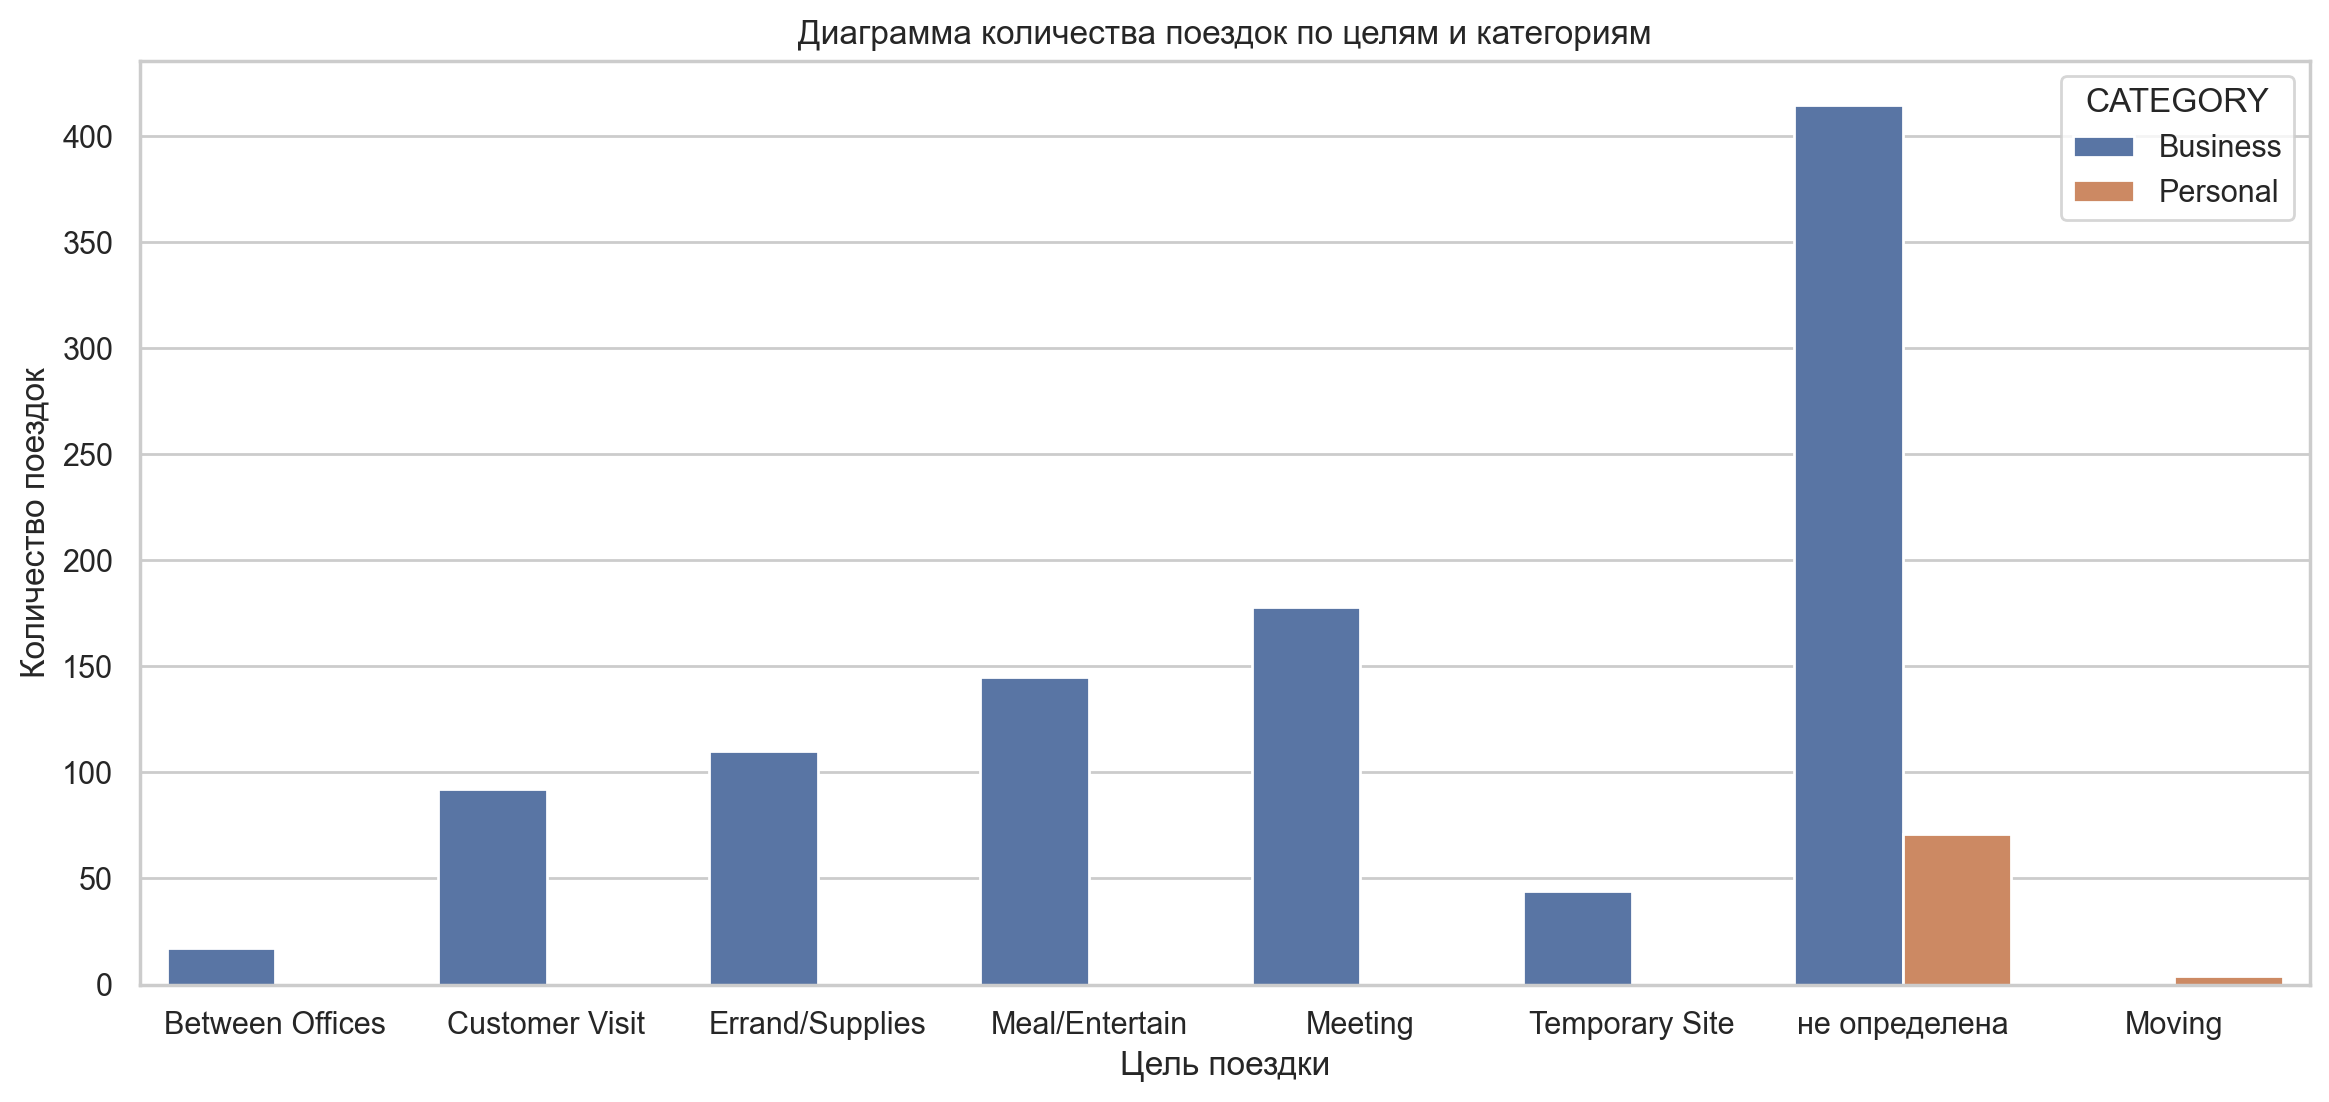

In [14]:
purpose_counts = (trips.groupby(['CATEGORY', 'PURPOSE'])
                       .size()
                       .reset_index(name='count')
                       .query('count > 2'))

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=purpose_counts, x='PURPOSE', y='count',
            hue='CATEGORY', ax=ax)
ax.set(title='Диаграмма количества поездок по целям и категориям',
       xlabel='Цель поездки', ylabel='Количество поездок')
plt.show()

Фильтр убрал Airport/Travel (2 поездки), Charity ($) и Commute (по одной). Почти все поездки деловые: 1003 из 1080. Чаще всего у деловых поездок указаны цели Meeting (178), Meal/Entertain (145) и Errand/Supplies (110), но самый высокий столбец — «не определена» (415). У личных поездок цель почти никогда не указана: 71 из 77, из указанных после фильтра остался только Moving (4).

### Задание 2

Pandas. Сводная таблица — среднее количество миль по каждой цели поездки, только маркеры ★ зелёного цвета размером 18.

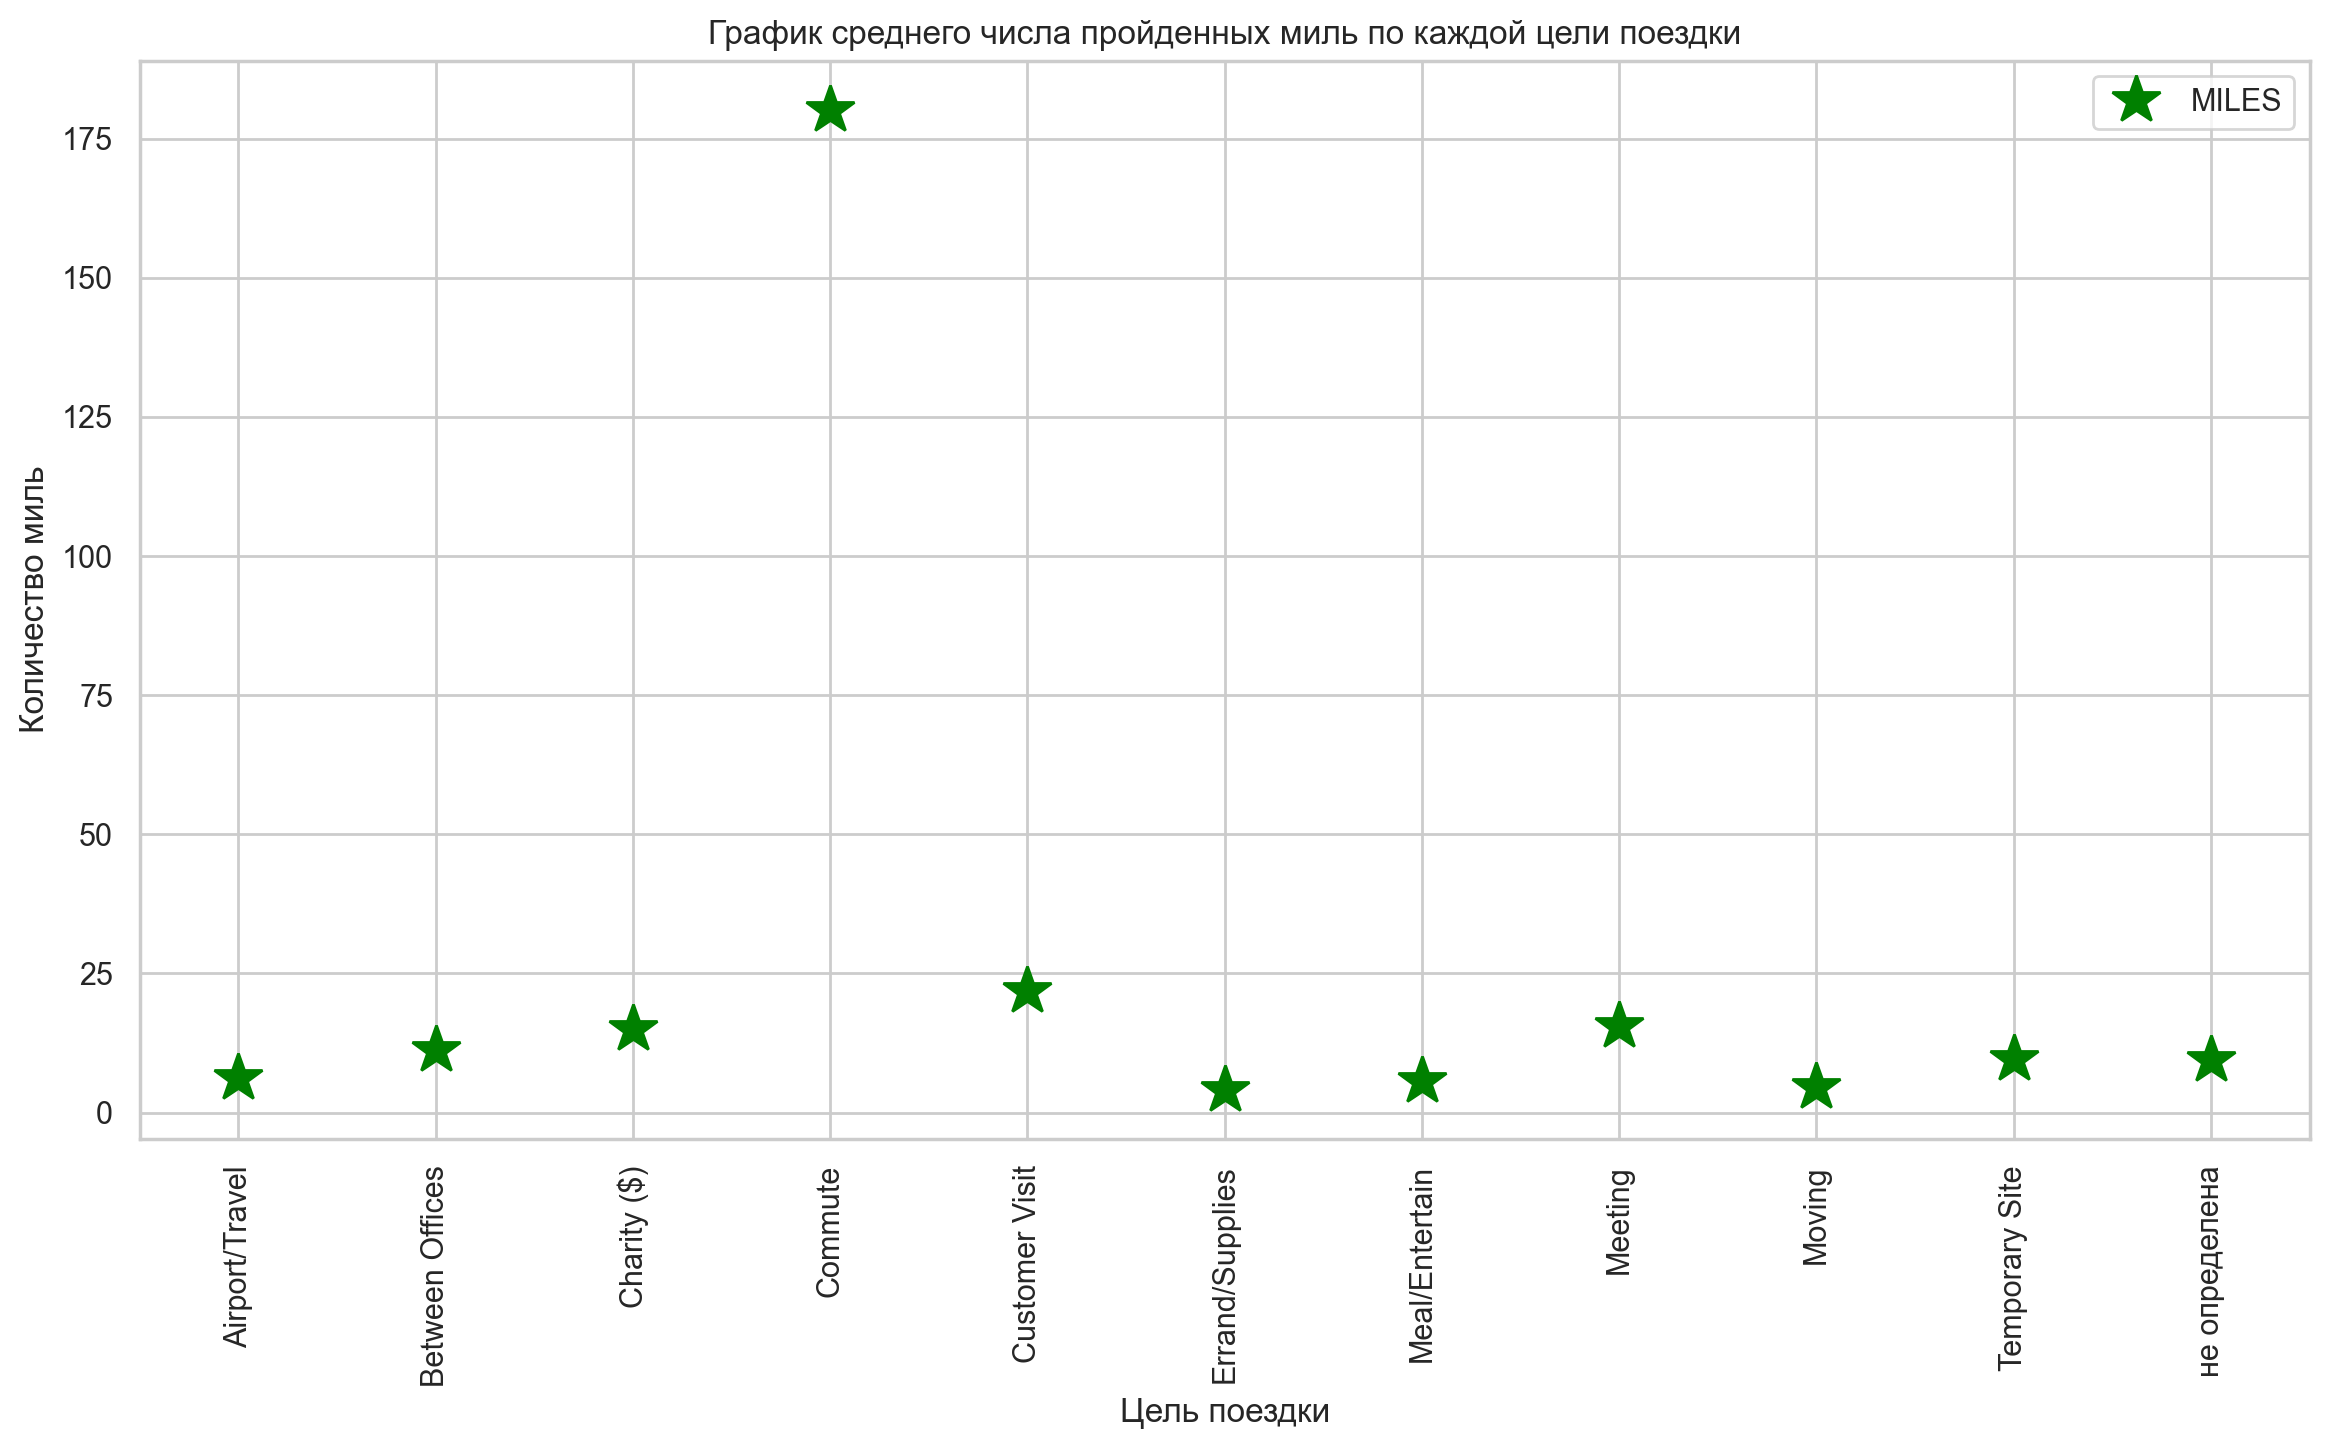

In [15]:
mean_miles = trips.pivot_table(index='PURPOSE', values='MILES',
                               aggfunc='mean')

ax = mean_miles.plot(style='*', color='green', markersize=18,
                     figsize=(14, 7), xticks=range(len(mean_miles)),
                     rot=90)
ax.set(title='График среднего числа пройденных миль по каждой цели поездки',
       xlabel='Цель поездки', ylabel='Количество миль')
plt.show()

Выше всех Commute — 180.2 мили, но это одна поездка, и о цели в целом она ничего не говорит. Остальные средние лежат в пределах 4–22 миль. Дальше всего в среднем ездят к клиентам (Customer Visit, 21.9) и на встречи (Meeting, 15.6), ближе всего — по поручениям (Errand/Supplies, 4.1), на переезд (Moving, 4.6) и на обед (Meal/Entertain, 5.7). Среднее чувствительно к дальним поездкам: у Customer Visit медиана всего 8.3 мили, это видно на диаграмме размаха в разделе 10.

### Задание 3

Matplotlib. Круговая диаграмма долей целей поездки, цели, у которых меньше 5 поездок, убраны.

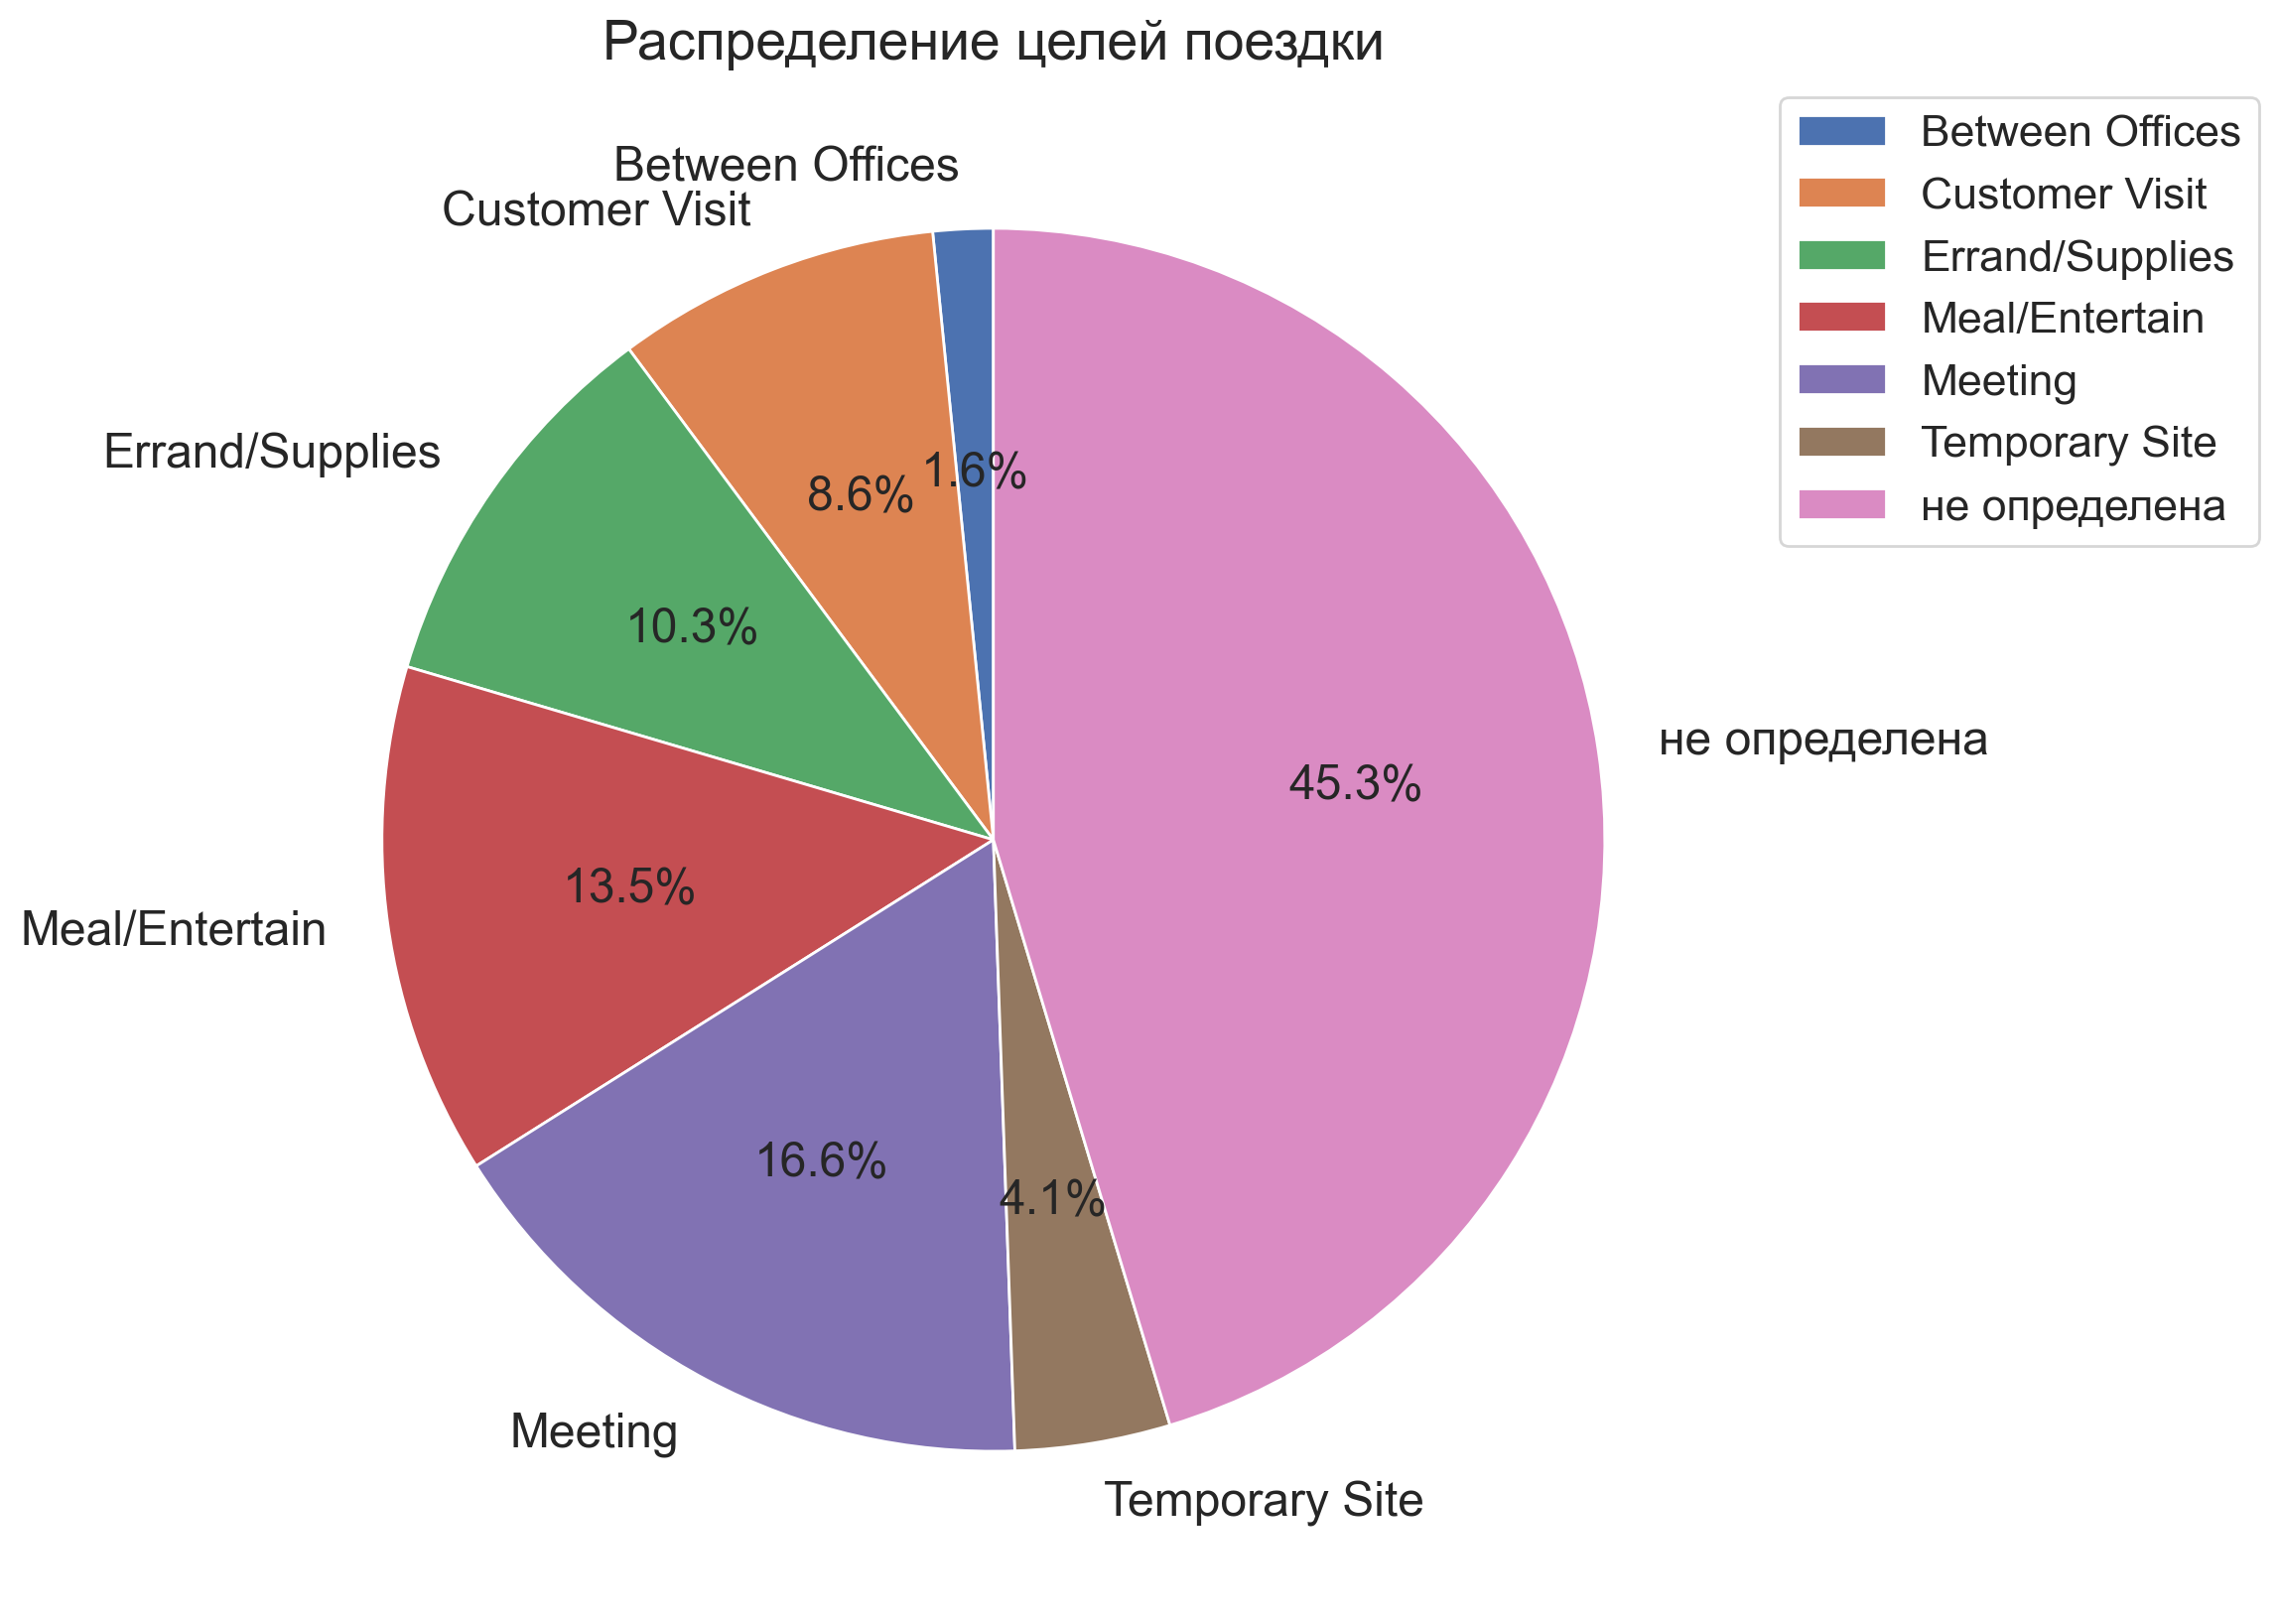

In [16]:
purpose_share = (trips['PURPOSE'].value_counts()
                                 .loc[lambda counts: counts >= MIN_TRIPS]
                                 .sort_index())

plt.figure(figsize=(20, 10))
plt.pie(purpose_share, labels=purpose_share.index, autopct='%1.1f%%',
        textprops={'size': 'x-large'}, startangle=90)
plt.title('Распределение целей поездки', fontsize=20)
plt.legend(fontsize=16, bbox_to_anchor=(1, 1))
plt.show()

Убраны Moving, Airport/Travel, Charity ($) и Commute — вместе 8 поездок. Почти половина диаграммы (45.3 %) — поездки без цели. Среди известных целей больше всего встреч (16.6 %), питания и развлечений (13.5 %) и поручений (10.3 %). На поездки к клиентам приходится 8.6 %, на временные площадки — 4.1 %, между офисами — 1.6 %.

## 7. Hexagonal binning plot

Строю плотность поездок по расстоянию и длительности. Чтобы редкие дальние поездки не растягивали оси, беру поездки до 30 миль и до 60 минут. Пустые шестиугольники не закрашиваются (`mincnt=1`).

Поездок до 30 миль и 60 минут: 1016 из 1080


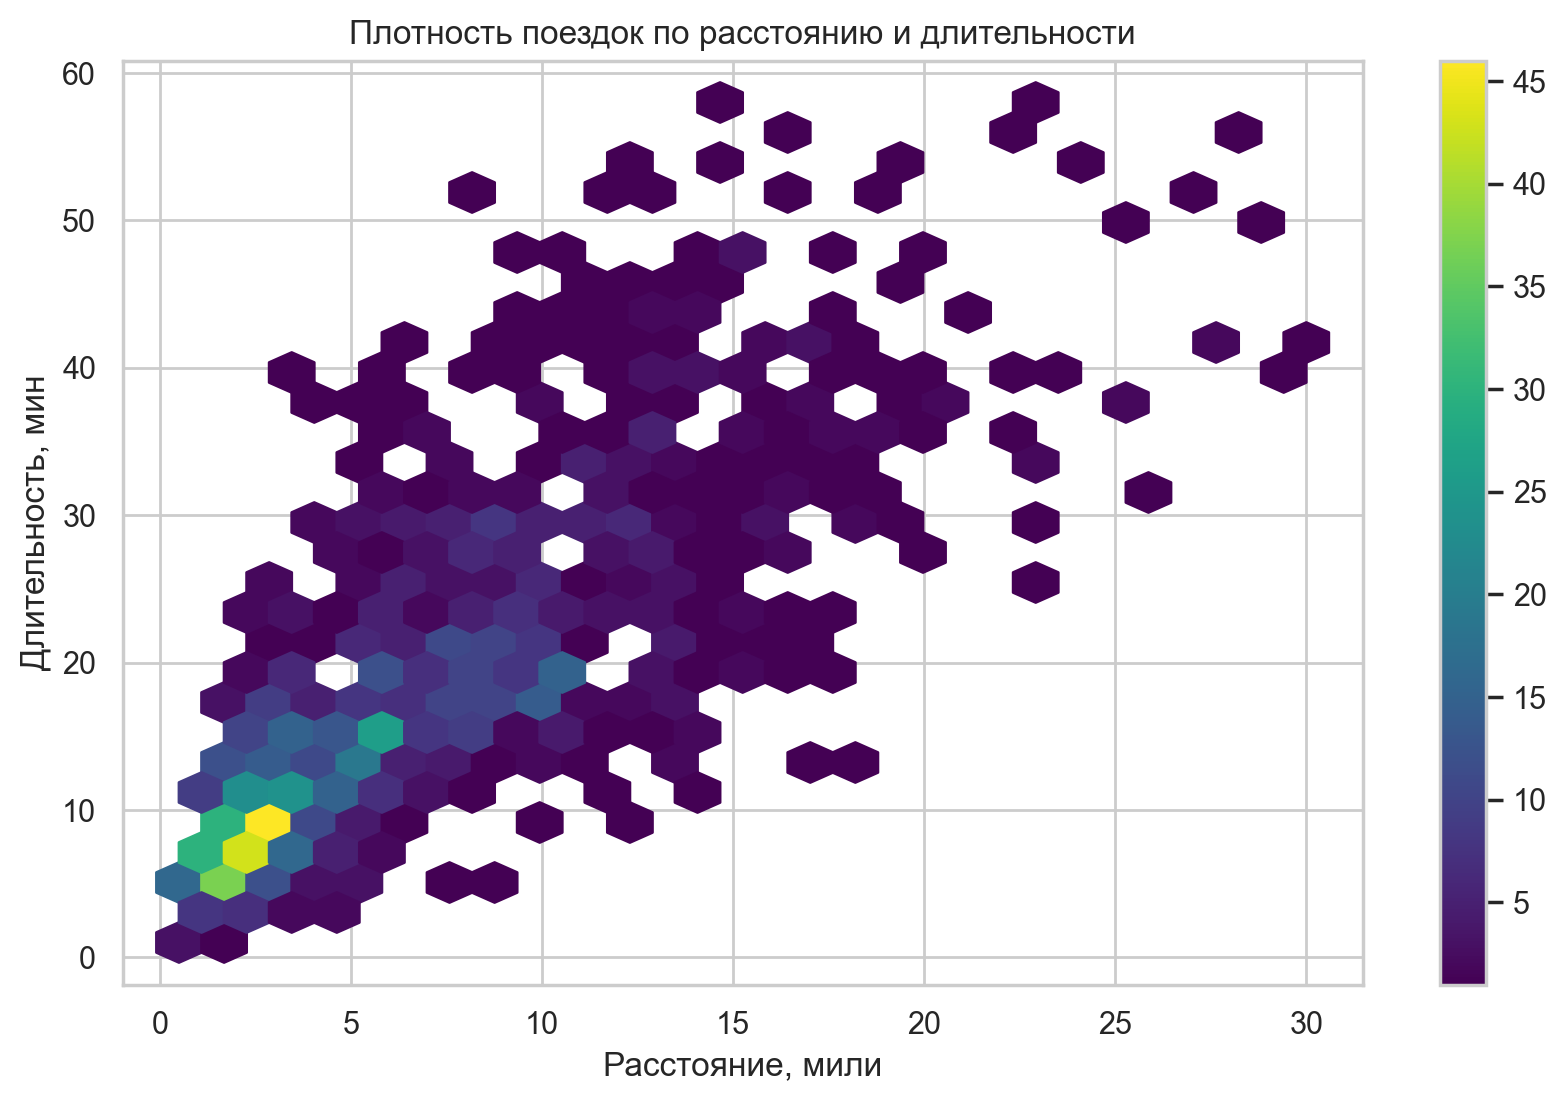

In [17]:
typical = trips.query('MILES <= 30 and time <= 60')
print(f'Поездок до 30 миль и 60 минут: {len(typical)} из {len(trips)}')

ax = typical.plot.hexbin(x='MILES', y='time', gridsize=25, mincnt=1, cmap='viridis',
                         figsize=(10, 6), sharex=False)
ax.set(xlabel=LABELS['MILES'], ylabel=LABELS['time'],
       title='Плотность поездок по расстоянию и длительности')
plt.show()

В выбранную область попадают 94 % поездок. Самые плотные ячейки — 1–4 мили и 5–10 минут, это типичная поездка по городу. Дальше плотность вытягивается полосой вдоль диагонали: на 10 миль половина поездок тратит от 18 до 29 минут. С расстоянием полоса расширяется — время поездки на одно и то же расстояние разбросано сильнее.

## 8. Диаграмма размаха стоимости

Matplotlib, столбец `price`.

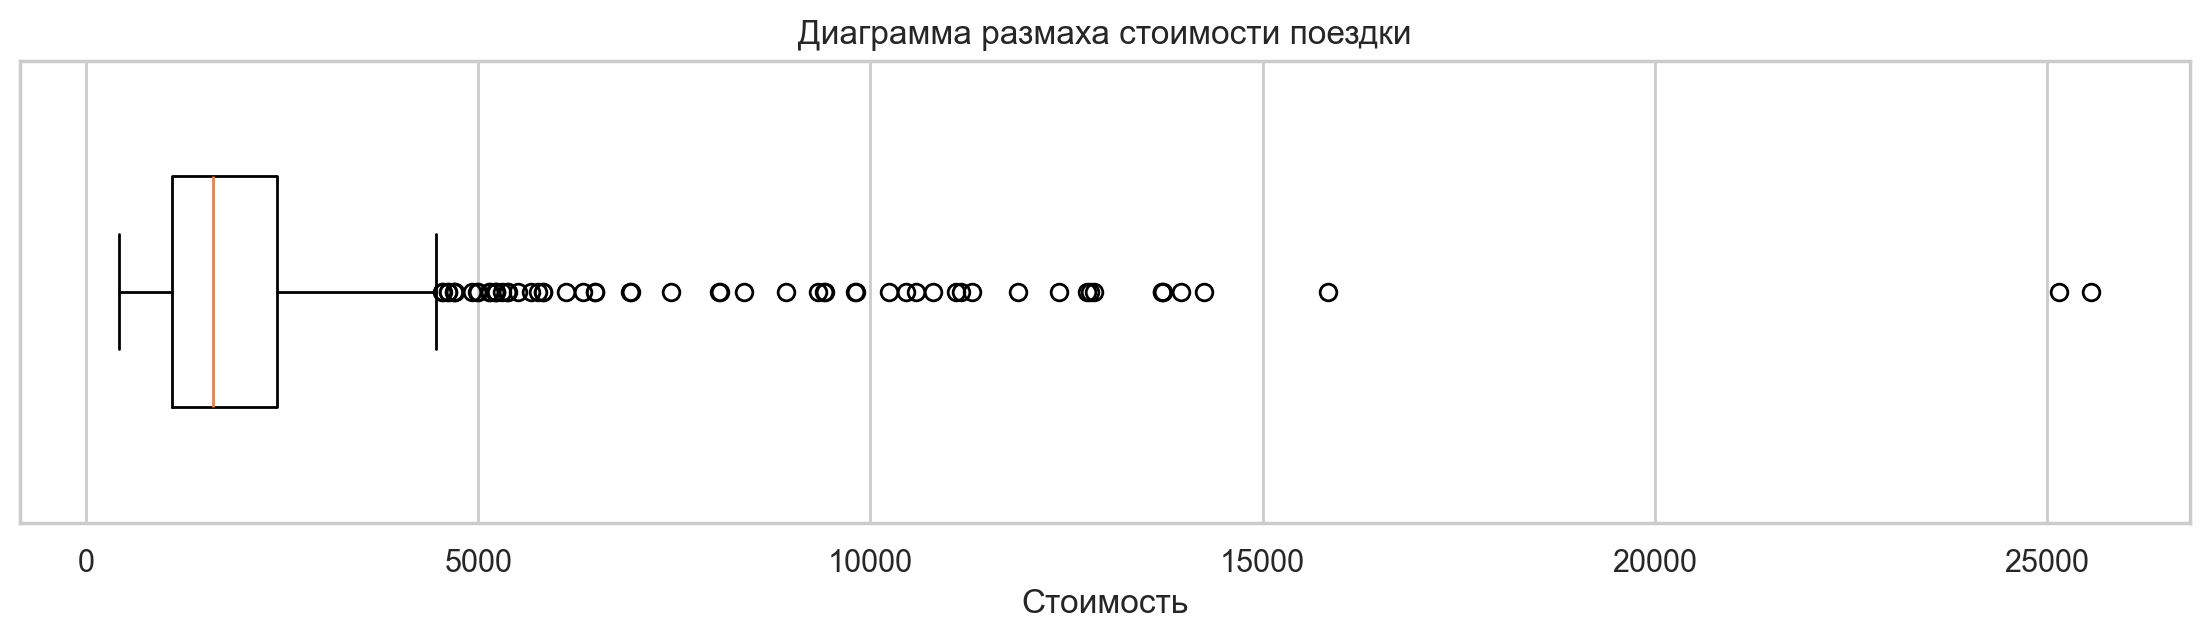

In [18]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.boxplot(trips['price'], vert=False, widths=0.5)
ax.set(xlabel=LABELS['price'], yticks=[], title='Диаграмма размаха стоимости поездки')
plt.show()

In [19]:
q1, median, q3 = trips['price'].quantile([0.25, 0.5, 0.75])
upper_whisker = q3 + 1.5 * (q3 - q1)
print(f'Q1 = {q1:.0f}, медиана = {median:.0f}, Q3 = {q3:.0f}')
print(f'Граница выбросов: {upper_whisker:.0f}')
print('Выбросов:', (trips['price'] > upper_whisker).sum())

Q1 = 1087, медиана = 1611, Q3 = 2437
Граница выбросов: 4462
Выбросов: 59


Половина поездок стоит от 1087 до 2437, медиана 1611 ближе к левому краю ящика. Левый ус короткий и заканчивается на минимуме 412, выбросов снизу нет. Справа за границей 4462 лежат 59 выбросов (5.5 % поездок), самые дорогие — две поездки около 25 000. Это не ошибки: 53 из 59 выбросов — поездки дальше 15 миль, а две самые дорогие длились около 5.5 часа. Распределение стоимости сильно скошено вправо, как и на гистограмме.

## 9. Категория дальности поездки

Добавляю категорию по расстоянию: короткая — до 5 миль, средняя — от 5 до 15, дальняя — больше 15. Границы круглые и близки к медиане (6 миль) и 90-му процентилю (17 миль) расстояния, поэтому дальними оказываются 13 % самых длинных поездок.

In [20]:
DISTANCE_BINS = [0, 5, 15, np.inf]
DISTANCE_NAMES = ['короткая', 'средняя', 'дальняя']

distance = pd.cut(trips['MILES'], bins=DISTANCE_BINS,
                  labels=DISTANCE_NAMES)
trips = trips.assign(distance=distance)
trips['distance'].value_counts()

distance
средняя     469
короткая    467
дальняя     144
Name: count, dtype: int64

Коротких и средних поездок почти поровну (467 и 469), дальних — 144. Рядом с расстоянием строю стоимость по тем же категориям, чтобы проверить, насколько дальность определяет цену. Оба графика в логарифмической шкале.

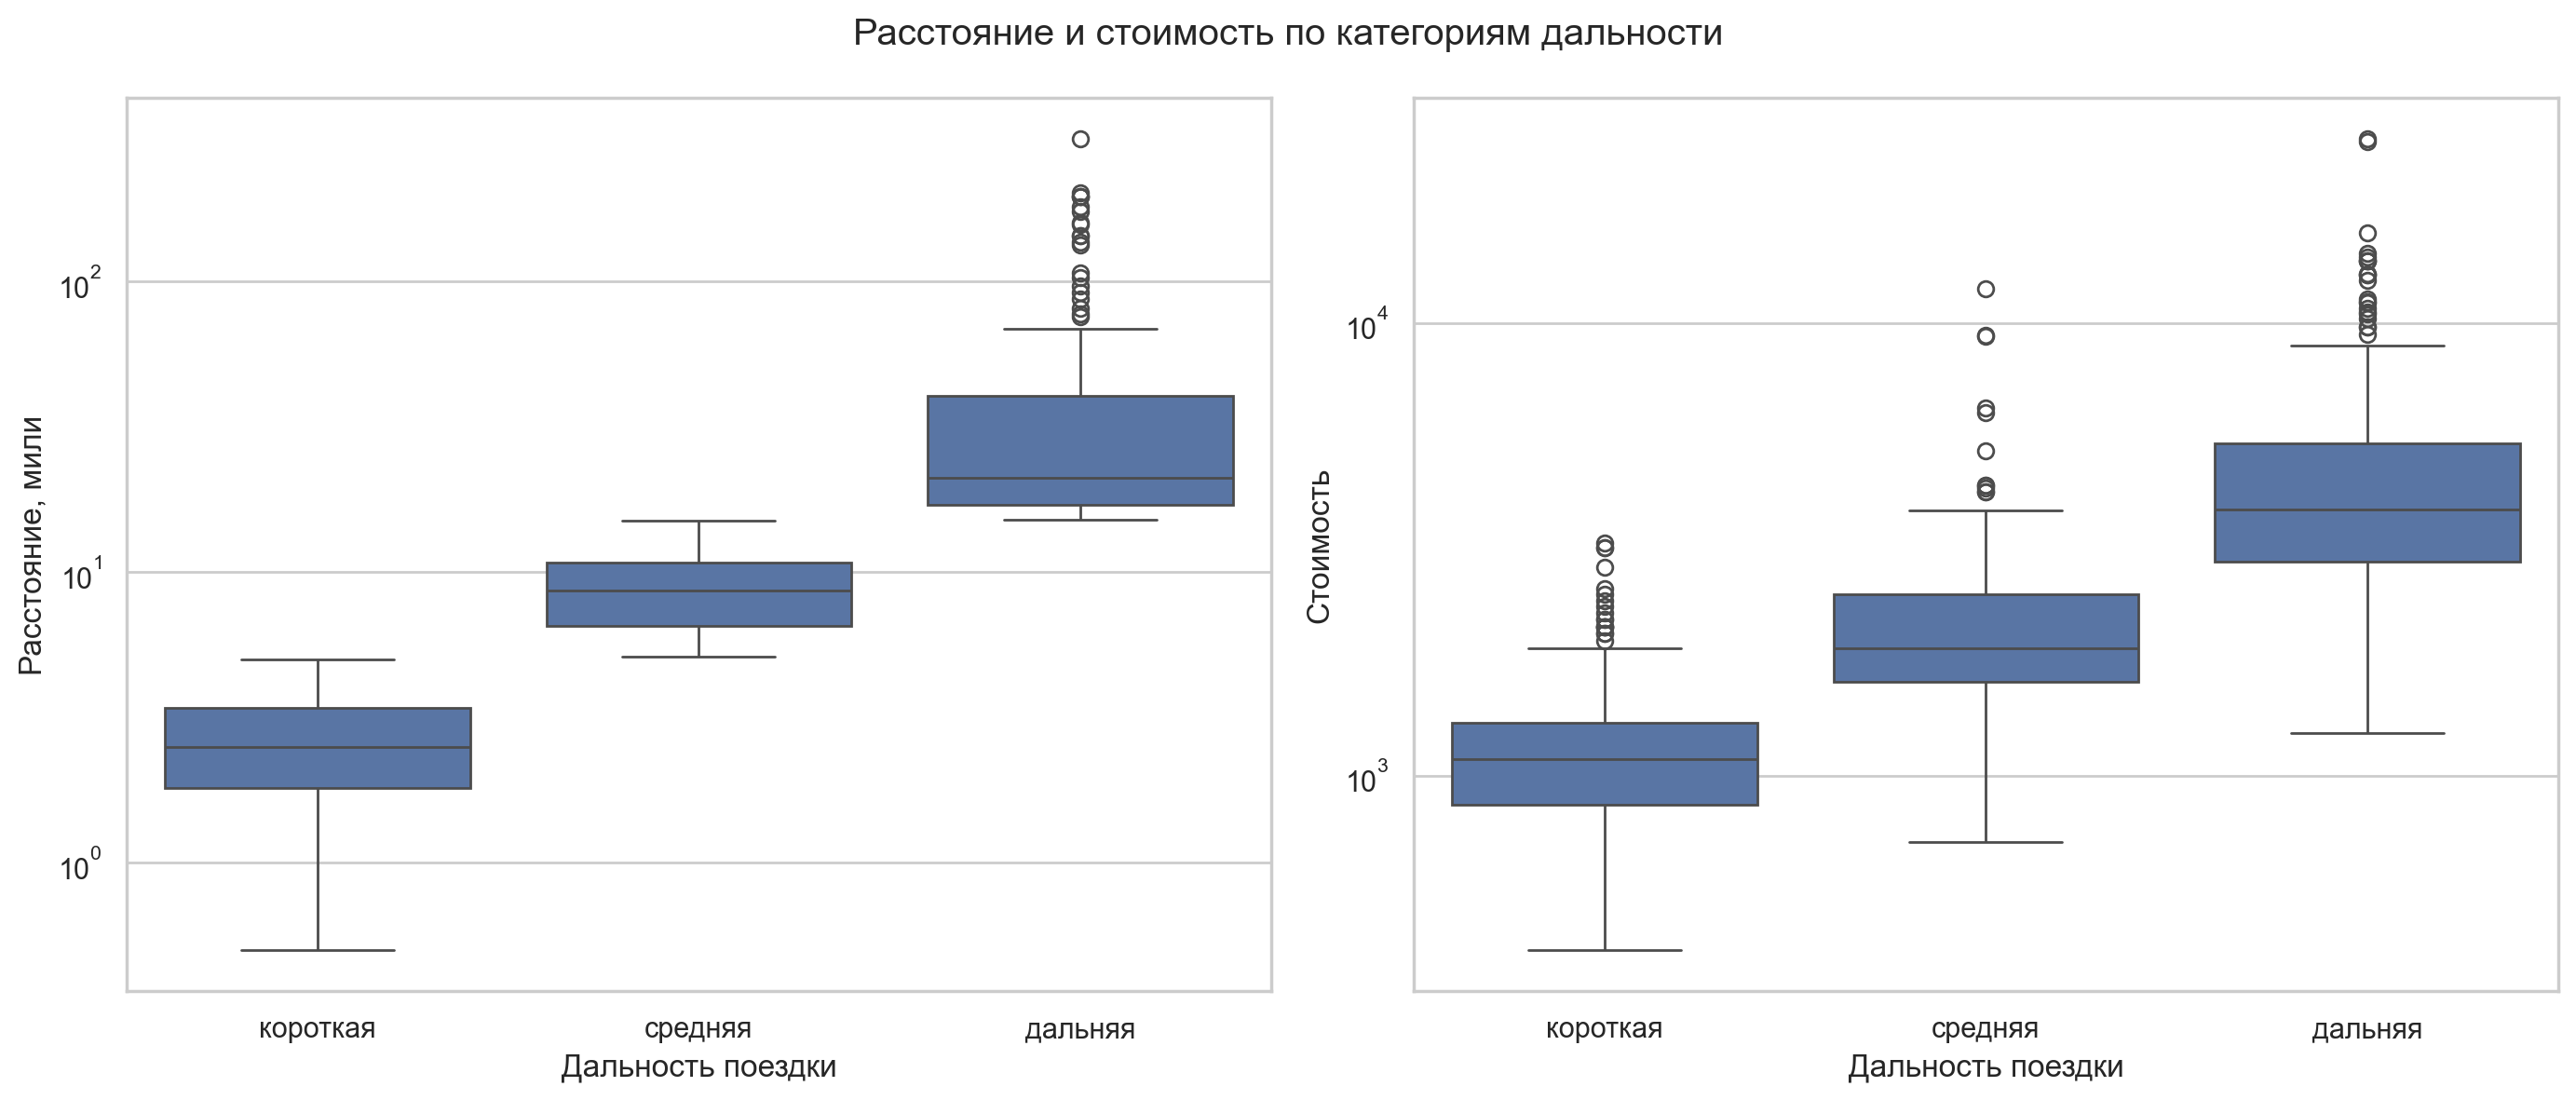

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, column in zip(axes, ['MILES', 'price']):
    sns.boxplot(data=trips, x='distance', y=column, ax=ax)
    ax.set(yscale='log', xlabel='Дальность поездки', ylabel=LABELS[column])

fig.suptitle('Расстояние и стоимость по категориям дальности')
fig.tight_layout()
plt.show()

Ящики расстояния не пересекаются — так задуманы категории. Медианы: 2.5, 8.6 и 21 миля. Внутри дальних поездок разброс самый большой: от 15 до 310 миль, выше 70 миль идут выбросы.

По стоимости медианы растут так же: 1087, 1913 и 3864. Ящики стоимости не пересекаются, но усы и выбросы соседних категорий перекрываются: 18 коротких поездок дороже медианы средних. Стоимость считается по времени, а короткая поездка может затянуться, например из-за пробок.

## 10. Диаграммы размаха по другим категориям

Скорость по категории поездки — pandas.

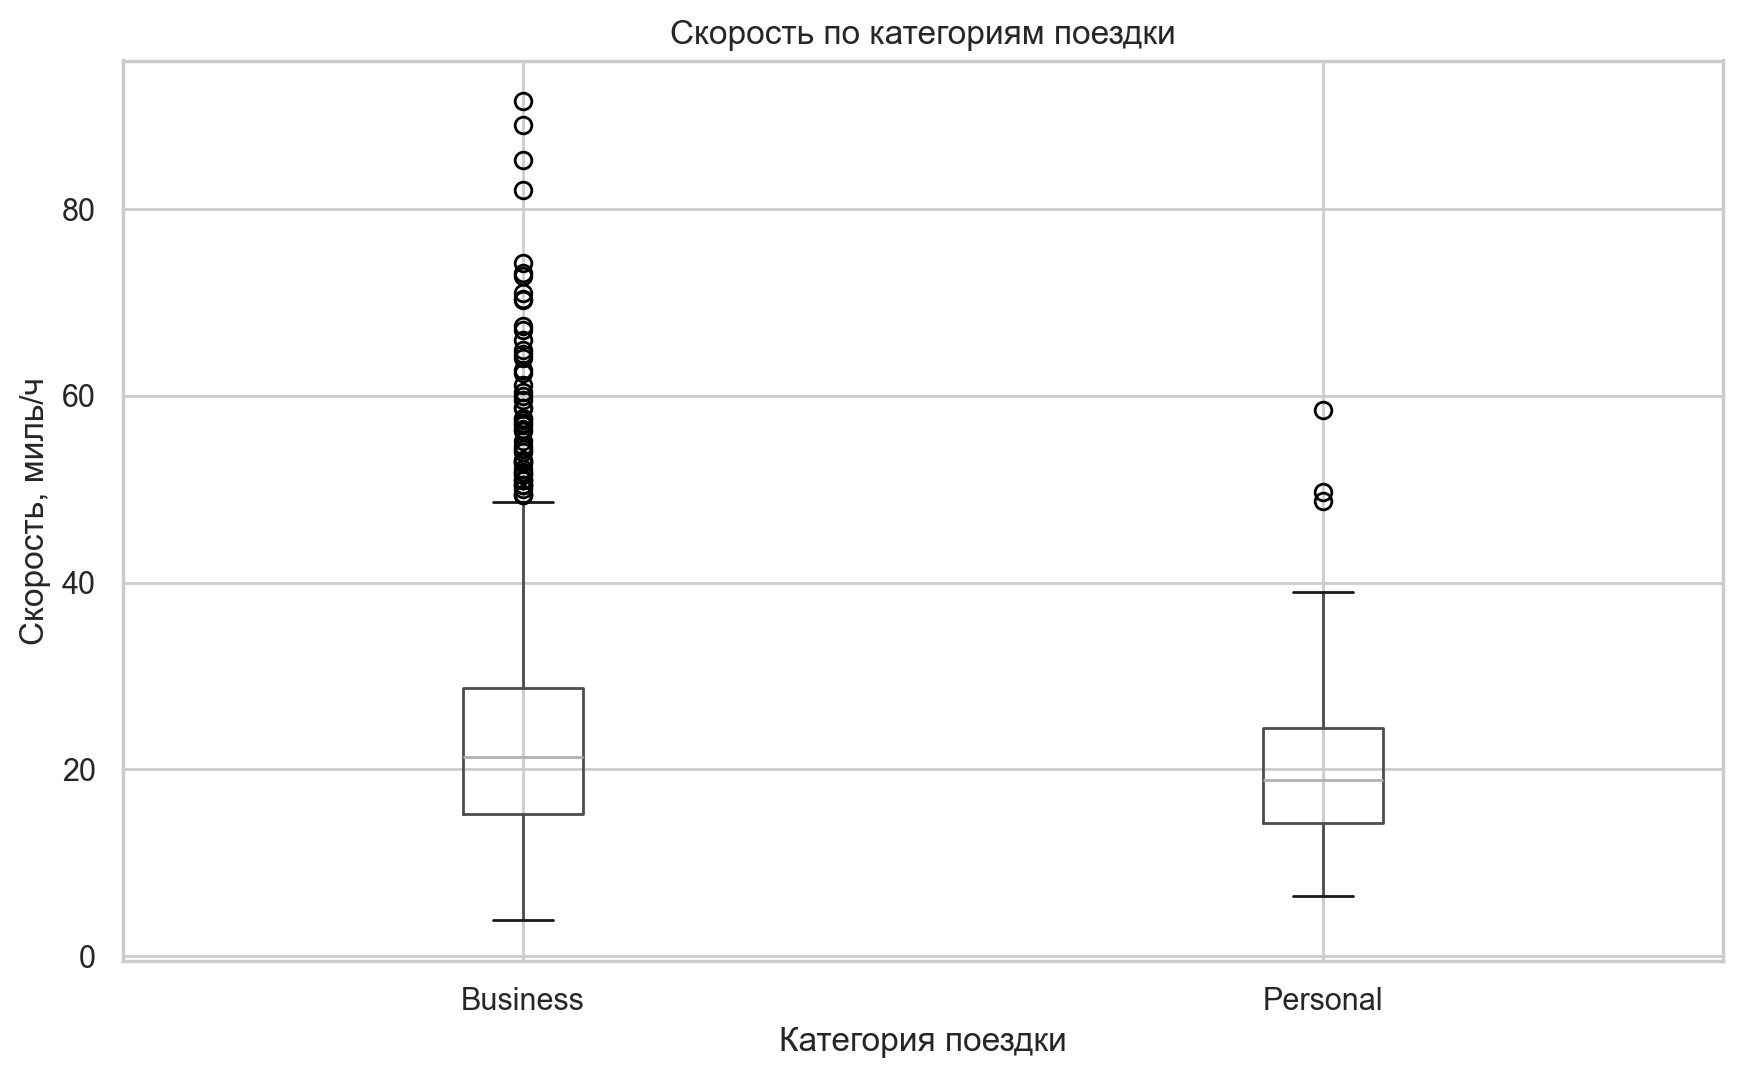

In [22]:
ax = trips.boxplot(column='speed', by='CATEGORY', figsize=(10, 6))
ax.set(xlabel='Категория поездки', ylabel=LABELS['speed'],
       title='Скорость по категориям поездки')
plt.suptitle('')
plt.show()

Медиана скорости деловых поездок 21.3 мили/ч, личных — 18.9. Половина деловых поездок идёт со скоростью 15–29 миль/ч, личных — 14–24. Разница небольшая. У деловых поездок много выбросов вверх до 91.5 миль/ч — это дальние поездки по трассе, у личных самая высокая скорость 58.4. К тому же личных поездок всего 77.

Расстояние по цели поездки — seaborn. Показаны цели, у которых не меньше 5 поездок, отсортированные по медиане расстояния, ось расстояния логарифмическая.

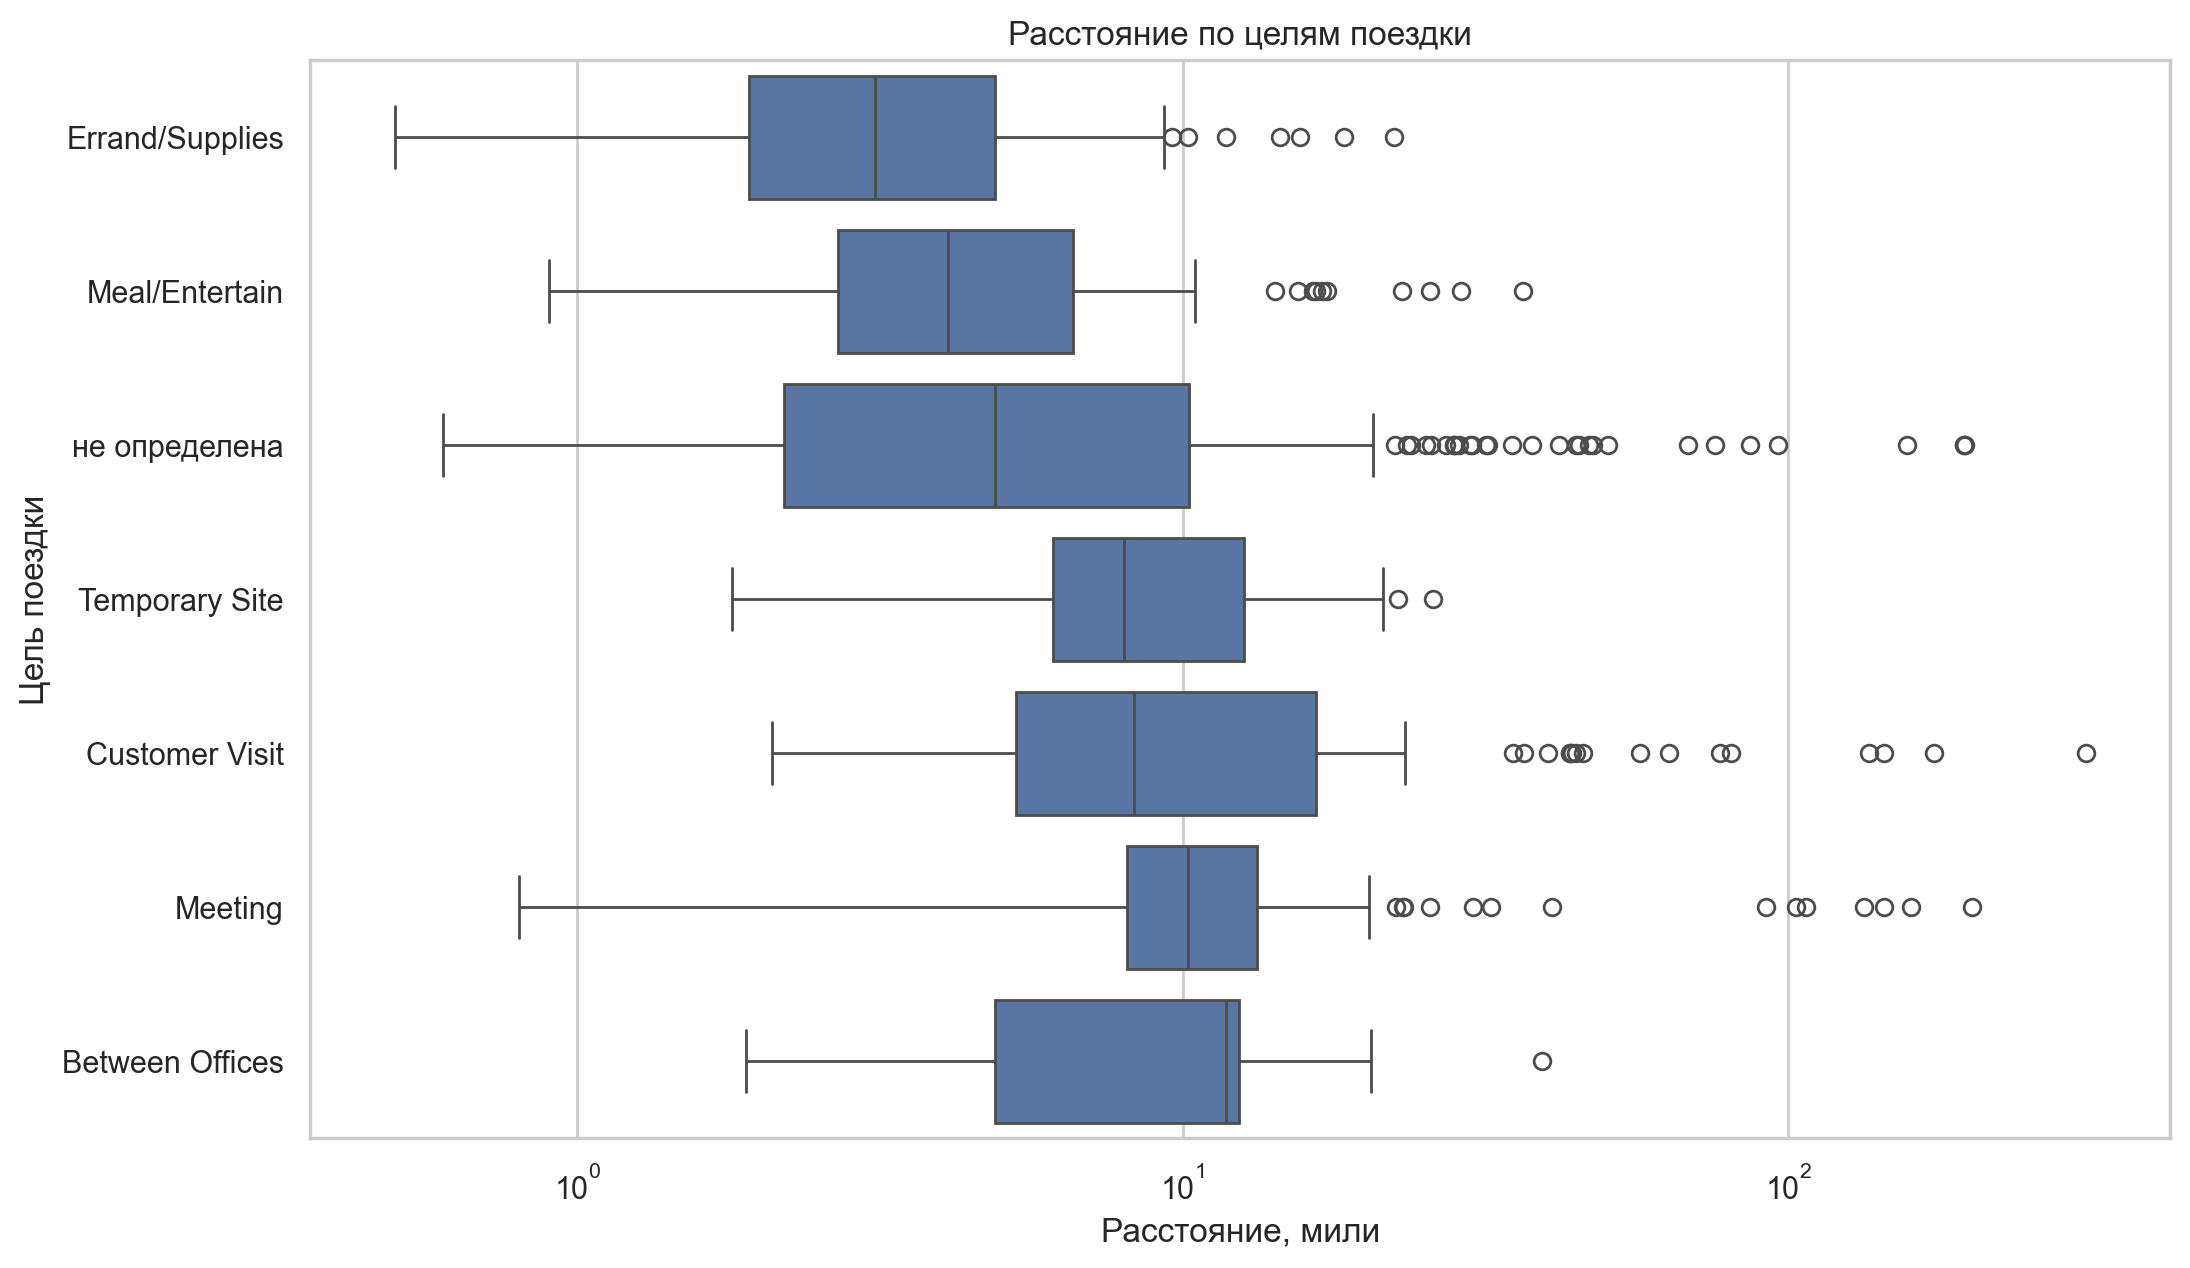

In [23]:
frequent_purpose = trips.groupby('PURPOSE').filter(lambda group: len(group) >= MIN_TRIPS)
purpose_order = frequent_purpose.groupby('PURPOSE')['MILES'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=frequent_purpose, x='MILES', y='PURPOSE', order=purpose_order, ax=ax)
ax.set(xscale='log', xlabel=LABELS['MILES'], ylabel='Цель поездки',
       title='Расстояние по целям поездки')
plt.show()

Цели делятся на две группы. Короткие — Errand/Supplies (медиана 3.1 мили) и Meal/Entertain (4.1): поручения и обеды обычно рядом. Длинные — Temporary Site (8.0), Customer Visit (8.3), Meeting (10.2) и Between Offices (11.8). У Customer Visit и Meeting много выбросов справа, до 100–300 миль: к клиентам и на встречи иногда ездят в другой город. Поэтому в задании 2 средние у этих целей получились намного больше медиан. У поездок без цели («не определена», медиана 4.9) самый широкий ящик: в эту группу попали поездки с разными целями.

## 11. Выводы

Исследован набор данных `drivers.csv` — 1099 поездок в такси за 2016 год с расстоянием, длительностью, скоростью, стоимостью, категорией и целью.

Предобработка:

- из названий столбцов убрана `*`, пропуски в цели поездки заменены на «не определена», даты переведены в `datetime`, `time` и `price` — в `int64`;
- удалены 19 поездок с ошибочной длительностью: 4 с нулевой и 15 со скоростью больше 100 миль/ч. Осталось 1080 поездок.

Результаты:

- расстояние, длительность и стоимость распределены с сильным хвостом вправо и близки к логнормальному распределению. Типичная поездка — около 6 миль и 17 минут, дальних поездок (больше 50 миль) всего 25;
- стоимость линейно зависит от длительности: около 335 за посадку и 75 за минуту, корреляция 1.00. От расстояния стоимость зависит только через время;
- расстояние сильно связано с длительностью и стоимостью (корреляция 0.85–0.87), со скоростью — умеренно (0.48 по Пирсону, 0.62 по Спирмену). Дальние поездки быстрее, так как идут по трассе. Отрицательных связей нет;
- 93 % поездок деловые. Скорость деловых и личных поездок почти не различается;
- у 45 % поездок цель не указана. Из известных целей чаще всего встречи, обеды и поручения;
- по расстоянию цели делятся на короткие (поручения и обеды, медиана 3–4 мили) и длинные (встречи, визиты к клиентам, поездки между офисами, медиана 8–12 миль). Средние расстояния у встреч и визитов к клиентам завышены редкими междугородними поездками, медиана описывает эти цели точнее.